# Frozen-model TCGA downstream benchmark

This notebook is the human-readable record for five-cohort cancer classification and pan-cancer overall-survival prediction. Our 45.6M FM and both BulkFormer models are frozen; identical PCA-128 downstream probes and five patient-level 80/20 splits are used. Published BulkRNABert values are included only as clearly separated literature references because they were generated on the authors' splits.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
HERE = Path.cwd() if Path.cwd().name == 'tcga_downstream' else Path('benchmarks/tcga_downstream')
RESULTS = HERE / 'results'
FIGURES = RESULTS / 'figures'; FIGURES.mkdir(exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Cohorts and endpoints

One deterministic primary-tumor aliquot is retained per TCGA patient. Classification combines GBM and LGG as GBMLGG. Survival uses curated PanCanAtlas overall-survival time and event labels.

In [2]:
cohort = pd.read_parquet(RESULTS / 'cohort_manifest.parquet')
cohort_summary = pd.read_parquet(RESULTS / 'cohort_summary.parquet')
display(pd.DataFrame([{'Primary-tumor patients': len(cohort),
    'Classification patients': int(cohort.classification_usable.sum()),
    'Survival patients': int(cohort.survival_usable.sum()),
    'Pan-cancer cohorts': cohort.cohort.nunique(),
    'Survival events': int(cohort.loc[cohort.survival_usable, 'event'].sum())}]).style.hide(axis='index'))
display(cohort_summary.style.format({'events': '{:.0f}'}).hide(axis='index'))

Primary-tumor patients,Classification patients,Survival patients,Pan-cancer cohorts,Survival events
9816,3227,9668,32,2774


cohort,patients,survival_usable,events,classification_usable
ACC,79,79,28,0
BLCA,408,406,179,408
BRCA,1093,1079,151,1093
CESC,304,291,71,0
CHOL,36,36,18,0
COAD,458,439,102,0
DLBC,48,47,9,0
ESCA,184,184,77,0
GBM,155,154,122,155
HNSC,502,501,217,0


## A. Common local benchmark

### A1. Five-cohort cancer classification

The primary comparison uses each complete frozen native embedding with the BulkRNABert-style classification MLP `[256, 128]`. The raw baseline uses all 25,150 TCGA expression columns directly. Identical patient-level train/validation/test splits, optimization, early stopping, and five seeds are used. PCA-128 linear probes remain available as secondary controls in the complete tables.

Model,native_features,probe,splits,macro_f1_mean,macro_f1_sd,weighted_f1_mean,weighted_f1_sd,balanced_accuracy_mean,balanced_accuracy_sd
BulkFormer-147M,643,native_mlp_256_128,5,0.9837,0.0066,0.9861,0.0055,0.9833,0.0065
BulkFormer-50M,259,native_mlp_256_128,5,0.9751,0.0073,0.9796,0.0061,0.9750,0.0088
Full raw expression,25150,native_mlp_256_128,5,0.9886,0.0046,0.9904,0.0040,0.9894,0.0046
Our FM (45.6M),512,native_mlp_256_128,5,0.9796,0.0068,0.9830,0.0057,0.9794,0.0079


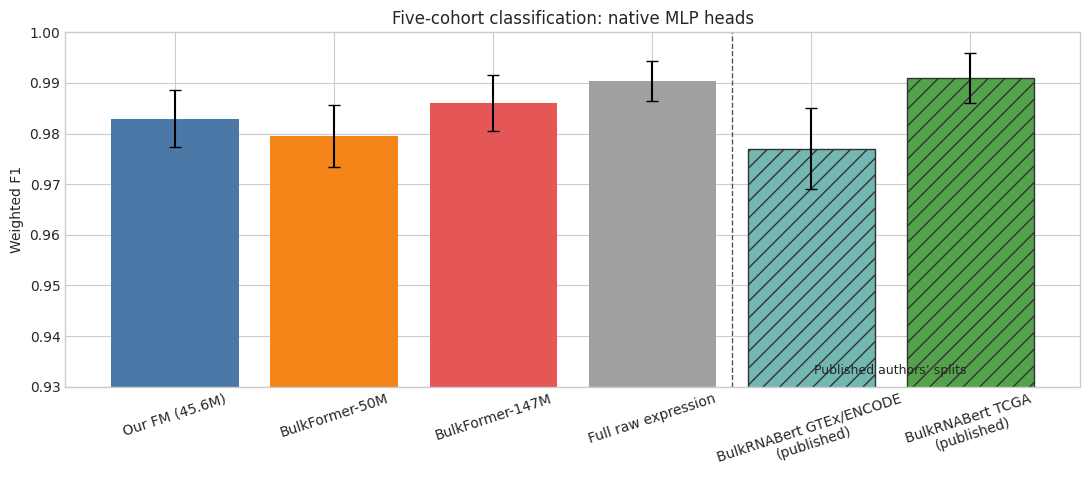

In [3]:
classification_linear = pd.read_parquet(RESULTS / 'classification_summary.parquet')
classification = pd.read_parquet(RESULTS / 'classification_mlp_summary.parquet')
labels = {'ours_45.6m': 'Our FM (45.6M)', 'bulkformer_50m': 'BulkFormer-50M',
          'bulkformer_147m': 'BulkFormer-147M', 'full_expression_25150': 'Full raw expression',
          'raw_expression': 'Raw expression PCA control'}
classification['Model'] = classification.representation.map(labels)
display(classification[['Model','native_features','probe','splits','macro_f1_mean','macro_f1_sd',
    'weighted_f1_mean','weighted_f1_sd','balanced_accuracy_mean','balanced_accuracy_sd']]
    .style.format({c: '{:.4f}' for c in classification.columns if c.endswith(('_mean','_sd'))}).hide(axis='index'))
primary_order = ['Our FM (45.6M)','BulkFormer-50M','BulkFormer-147M','Full raw expression']
plot = classification.set_index('Model').loc[primary_order]
published = pd.read_parquet(RESULTS / 'published_reference_results.parquet')
refs = published[(published.task.eq('five_cohort_classification')) & published.metric.eq('weighted_f1') &
                 published.method.str.startswith('BulkRNABert')].copy()
names = list(plot.index) + ['BulkRNABert GTEx/ENCODE\n(published)', 'BulkRNABert TCGA\n(published)']
values = list(plot.weighted_f1_mean) + [refs.loc[refs.method.str.contains('GTEx'), 'mean'].iloc[0],
    refs.loc[refs.method.eq('BulkRNABert(TCGA)+SVM'), 'mean'].iloc[0]]
errors = list(plot.weighted_f1_sd) + [refs.loc[refs.method.str.contains('GTEx'), 'sd'].iloc[0],
    refs.loc[refs.method.eq('BulkRNABert(TCGA)+SVM'), 'sd'].iloc[0]]
fig, ax = plt.subplots(figsize=(11,5)); bars = ax.bar(names, values, yerr=errors, capsize=4,
    color=['#4C78A8','#F58518','#E45756','#A0A0A0','#72B7B2','#54A24B'])
for bar in bars[-2:]: bar.set_hatch('//'); bar.set_edgecolor('#333333')
ax.axvline(3.5, color='#555555', linestyle='--', linewidth=1)
ax.text(4.5, .932, 'Published authors’ splits', ha='center', va='bottom', fontsize=9)
ax.set(ylabel='Weighted F1', title='Five-cohort classification: native MLP heads', ylim=(.93,1.0)); ax.tick_params(axis='x',rotation=18)
fig.tight_layout(); fig.savefig(FIGURES/'classification_weighted_f1.png',dpi=250,bbox_inches='tight'); plt.show()

### A2. Pan-cancer overall survival

The primary comparison uses each complete frozen native embedding with the BulkRNABert-style survival MLP `[512, 256]`, trained using Cox partial-likelihood loss. The raw baseline uses all 25,150 TCGA expression columns directly. Pooled C-index measures global ranking; weighted and macro C-index summarize within-cohort discrimination. PCA-128 Cox probes remain secondary controls.

Model,native_features,probe,splits,c_index_mean,c_index_sd,weighted_c_index_mean,weighted_c_index_sd,macro_c_index_mean,macro_c_index_sd
BulkFormer-147M,643,native_mlp_512_256_cox,5,0.7620,0.0120,0.6320,0.0202,0.6242,0.0225
BulkFormer-50M,259,native_mlp_512_256_cox,5,0.7588,0.0113,0.6168,0.0329,0.6119,0.0217
Full raw expression,25150,native_mlp_512_256_cox,5,0.7610,0.0146,0.6145,0.0136,0.6119,0.0190
Our FM (45.6M),512,native_mlp_512_256_cox,5,0.7597,0.0111,0.5995,0.0260,0.5963,0.0350


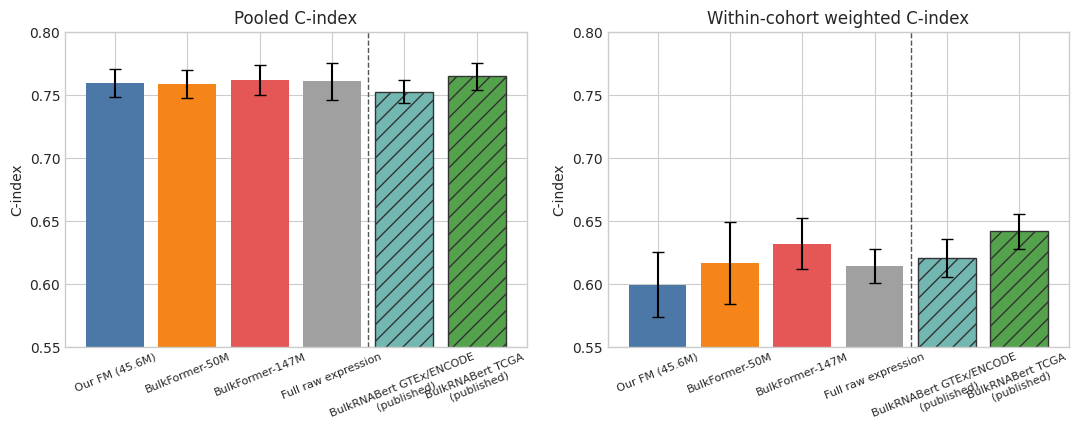

In [4]:
survival_linear = pd.read_parquet(RESULTS / 'survival_summary.parquet')
survival = pd.read_parquet(RESULTS / 'survival_mlp_summary.parquet')
survival['Model'] = survival.representation.map(labels)
display(survival[['Model','native_features','probe','splits','c_index_mean','c_index_sd','weighted_c_index_mean',
    'weighted_c_index_sd','macro_c_index_mean','macro_c_index_sd']]
    .style.format({c: '{:.4f}' for c in survival.columns if c.endswith(('_mean','_sd'))}).hide(axis='index'))
plot = survival.set_index('Model').loc[primary_order]
published_survival = pd.read_parquet(RESULTS / 'published_reference_results.parquet')
published_survival = published_survival[published_survival.task.eq('pan_cancer_survival') &
    published_survival.method.str.startswith('BulkRNABert')]
reference_names = ['BulkRNABert GTEx/ENCODE\n(published)', 'BulkRNABert TCGA\n(published)']
fig, axes = plt.subplots(1,2,figsize=(11,4.5))
for ax, metric, title in [(axes[0],'c_index','Pooled C-index'),(axes[1],'weighted_c_index','Within-cohort weighted C-index')]:
    refs = published_survival[published_survival.metric.eq(metric)].set_index('method')
    names = list(plot.index) + reference_names
    values = list(plot[f'{metric}_mean']) + [refs.loc['BulkRNABert(GTEx ENCODE)','mean'], refs.loc['BulkRNABert(TCGA)','mean']]
    errors = list(plot[f'{metric}_sd']) + [refs.loc['BulkRNABert(GTEx ENCODE)','sd'], refs.loc['BulkRNABert(TCGA)','sd']]
    bars = ax.bar(names, values, yerr=errors, capsize=4,
           color=['#4C78A8','#F58518','#E45756','#A0A0A0','#72B7B2','#54A24B'])
    for bar in bars[-2:]: bar.set_hatch('//'); bar.set_edgecolor('#333333')
    ax.axvline(3.5, color='#555555', linestyle='--', linewidth=1)
    ax.set(ylabel='C-index',title=title,ylim=(.55,.80)); ax.tick_params(axis='x',rotation=22, labelsize=8)
fig.tight_layout(); fig.savefig(FIGURES/'survival_c_index.png',dpi=250,bbox_inches='tight'); plt.show()

### A2.1 Per-cancer survival discrimination

These forest plots calculate C-index **within each cancer** from the existing held-out Cox risk predictions. Censoring and observed survival times are retained. The original protocol consists of five repeated stratified 80/20 splits rather than exhaustive K-fold OOF prediction: concordance pairs are therefore formed only within each seed's held-out set and then aggregated by comparable-pair count. Some patients appear in multiple held-out splits and some in none.

Confidence intervals are percentile intervals from 1,000 patient-level bootstrap resamples within cancer (fixed seed 20260922). A patient's survival outcome and all held-out appearances stay together. Event counts are shown because sparse-event estimates can look extreme while remaining highly uncertain. Flags identify fewer than 10 events as `very_low_event_support`, 10–19 as `low_event_support`, CI width above 0.25 as `wide_ci`, and fewer than 900 valid bootstrap replicates as `unreliable_bootstrap`.

In [5]:
per_cancer_survival = pd.read_csv('results/per_cancer_survival_metrics.csv')
bridge_survival = per_cancer_survival.query("representation == 'Bridge 45.6M'")
display(bridge_survival[['cancer', 'n_patients', 'n_events', 'n_censored',
                         'censoring_fraction', 'comparable_pairs', 'c_index',
                         'ci_low', 'ci_high', 'bootstrap_valid', 'stability_flag']]
        .sort_values('cancer').style.format({
            'censoring_fraction': '{:.1%}', 'c_index': '{:.3f}',
            'ci_low': '{:.3f}', 'ci_high': '{:.3f}'}).hide(axis='index'))

cancer,n_patients,n_events,n_censored,censoring_fraction,comparable_pairs,c_index,ci_low,ci_high,bootstrap_valid,stability_flag
ACC,54,23,31,57.4%,368,0.796,0.696,0.890,1000,stable
BLCA,269,120,149,55.4%,8877,0.616,0.559,0.669,1000,stable
BRCA,726,97,629,86.6%,11525,0.545,0.476,0.619,1000,stable
CESC,201,49,152,75.6%,2266,0.685,0.592,0.767,1000,stable
CHOL,23,12,11,47.8%,66,0.682,0.409,0.879,1000,low_event_support;wide_ci
COAD,298,68,230,77.2%,5557,0.610,0.529,0.684,1000,stable
DLBC,30,6,24,80.0%,51,0.392,0.077,0.640,998,very_low_event_support;wide_ci
ESCA,130,53,77,59.2%,1554,0.522,0.411,0.623,1000,stable
GBM,110,86,24,21.8%,1800,0.552,0.468,0.632,1000,stable
HNSC,336,147,189,56.2%,13321,0.595,0.532,0.658,1000,stable


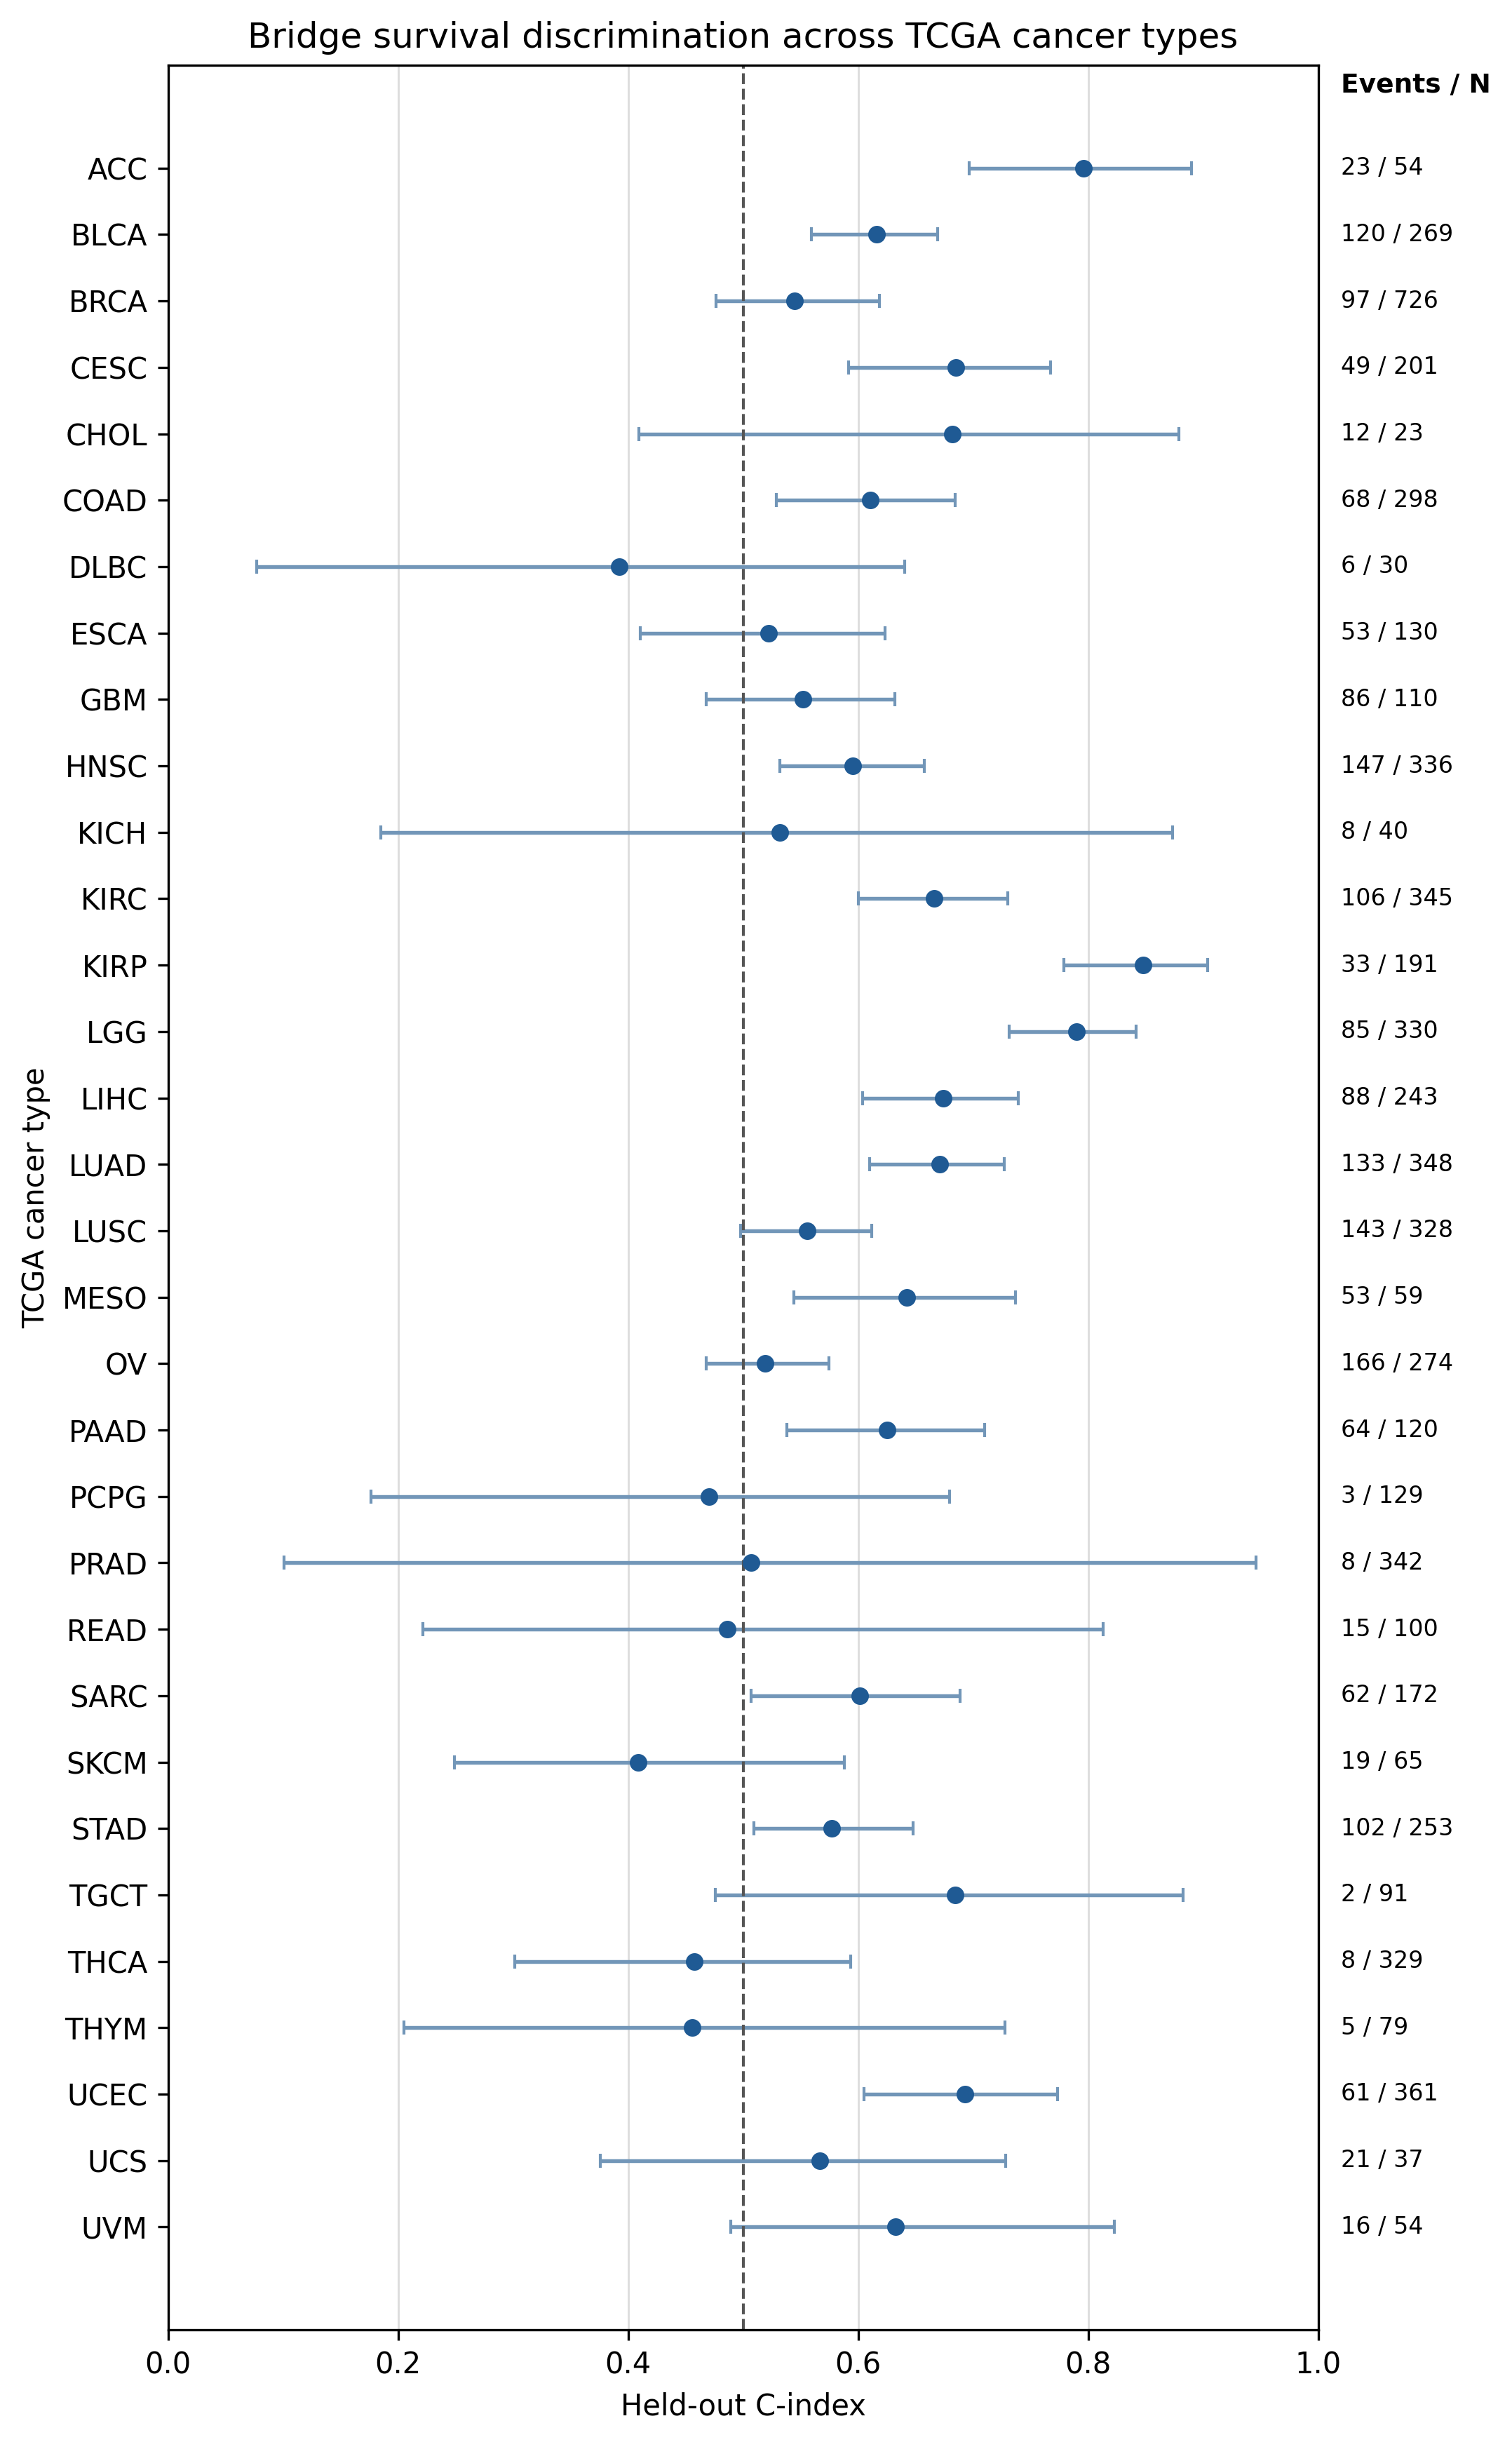

In [6]:
from IPython.display import Image
display(Image(filename=str(FIGURES / 'bridge_per_cancer_survival_forest.png')))

The alphabetical Bridge-only forest plot is the manuscript-facing default. The companion plot below uses the same cancers and x-axis limits for the conventional PCA-128 and full-expression controls. Both controls use the exact same held-out patients as Bridge; PCA and all learned preprocessing were fitted on training patients only.

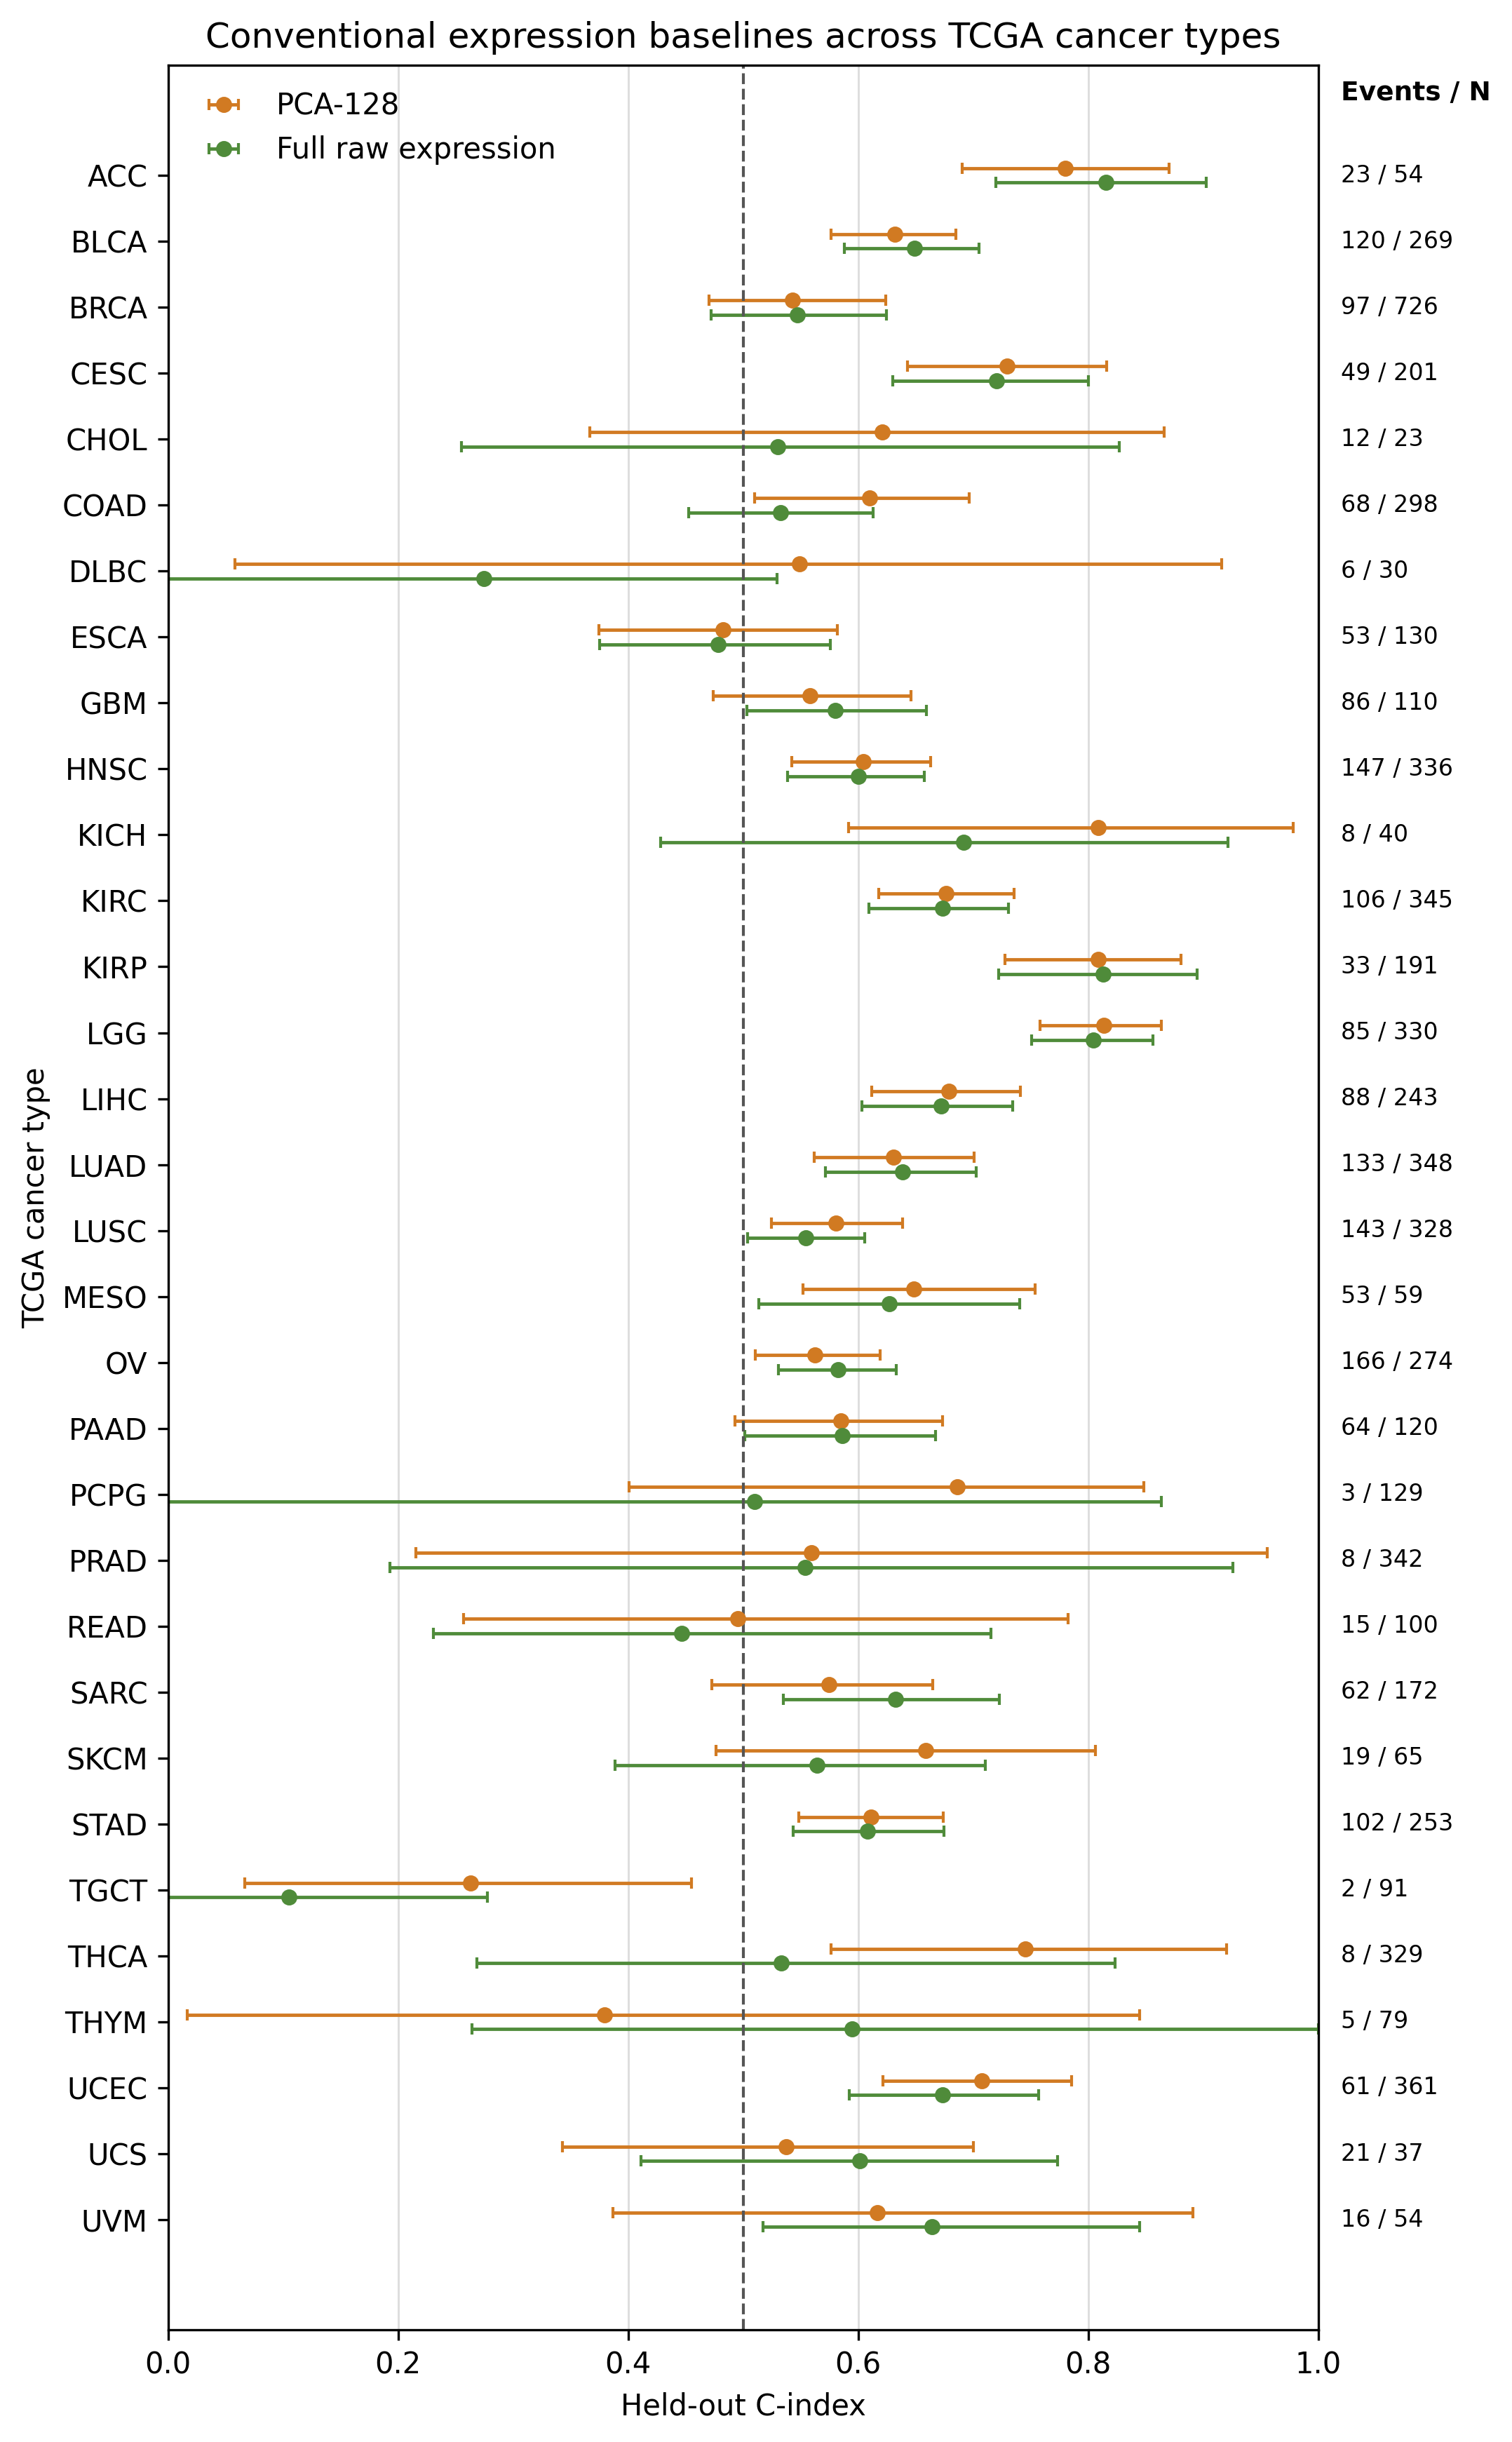

In [7]:
display(Image(filename=str(FIGURES / 'conventional_per_cancer_survival_forest.png')))

In [8]:
survival_stats = pd.read_csv('results/per_cancer_survival_statistical_summary.csv')
display(survival_stats.style.format({'value': '{:.4g}'}).hide(axis='index'))

summary,value
median_bridge_c_index,0.5983
patient_weighted_mean_bridge_c_index,0.6032
bridge_cancers_gt_0.5,26
bridge_cancers_le_0.5,6
bridge_ci_excludes_0.5,15
median_pca128_c_index,0.6139
median_full_raw_c_index,0.5974
median_bridge_minus_pca128,-0.007733
cancers_bridge_gt_pca128,13
paired_signflip_mean_p_pca128,0.3548


Across the 32 cancers, Bridge's median within-cancer C-index is 0.598 and its patient-count-weighted mean is 0.603. Bridge is above 0.5 in 26 cancers; 15 cancer-specific intervals exclude 0.5. Bridge exceeds PCA-128 and full raw expression in 13 cancers each. The paired median differences are −0.008 versus PCA and −0.011 versus raw expression; neither the paired sign-flip tests nor Wilcoxon tests indicate a systematic difference (all p > 0.35). A nonsignificant result is not evidence of equivalence.

The strongest well-supported Bridge estimates are KIRP, ACC, LGG, UCEC, CESC, LIHC, LUAD, and KIRC. Estimates near or below chance include PRAD, READ, PCPG, THCA, THYM, SKCM, and DLBC, but PRAD, PCPG, THCA, THYM, and DLBC have fewer than 10 events, while READ and SKCM have fewer than 20; these should not be read as stable failures. Conversely, TGCT's apparently high C-index is based on only two events and is not reliable. The pooled pan-cancer C-index remains a separate quantity that can exploit between-cancer prognosis differences; these within-cancer plots do not replace it.

## Complete 5-fold out-of-fold survival evaluation

The authoritative primary-tumor manifest contains 9,816 patients. The unchanged OS eligibility rule retains 9,668 patients and 2,774 events; 21 patients lack a valid binary event, 34 have a valid event but missing time, and 93 have nonpositive time. The original five repeated 80/20 tests measure split-to-split stability, but overlapping test sets are expected: only 6,467 of 9,668 eligible patients appeared at least once. This fixed true five-fold evaluation partitions all 9,668 patients into mutually exclusive test folds, balanced deterministically within cancer × event strata. Every patient is trained against in four folds and receives exactly one prediction from the remaining fold.

Bridge remained frozen and its cached embeddings were reused; only the established `[512, 256]` downstream Cox heads were fitted. Full expression uses the same head and training-fold standardization. PCA-128 and its scaler are fitted independently inside each training fold, followed by the existing penalized Cox model. Overall and cancer-specific concordance is **fold-aware**: concordant and comparable-pair counts are summed across held-out folds, but risk scores from separately fitted heads are never compared across folds. Patient-level bootstrap resampling retains each patient's fixed fold membership (1,000 draws, seed 20260923).

In [9]:
oof_metrics = pd.read_csv('results/survival_5fold_oof_metrics.csv')
oof_metrics.style.format({'oof_survival_c_index': '{:.3f}', 'comparable_pairs': '{:,.0f}'}).hide(axis='index')

representation,oof_survival_c_index,comparable_pairs,aggregation
Bridge 45.6M,0.758,"3,068,664",fold-aware pair-weighted
PCA-128,0.762,"3,068,664",fold-aware pair-weighted
Full raw expression,0.759,"3,068,664",fold-aware pair-weighted


In [10]:
oof_per_cancer = pd.read_csv('results/survival_5fold_oof_per_cancer.csv')
display(oof_per_cancer.query("representation == 'Bridge 45.6M'")
        [['cancer', 'n_patients', 'n_events', 'n_censored', 'censoring_fraction',
          'comparable_pairs', 'c_index', 'ci_low', 'ci_high', 'bootstrap_valid', 'stability_flag']]
        .sort_values('cancer').style.format({'censoring_fraction': '{:.1%}',
            'c_index': '{:.3f}', 'ci_low': '{:.3f}', 'ci_high': '{:.3f}'}).hide(axis='index'))

cancer,n_patients,n_events,n_censored,censoring_fraction,comparable_pairs,c_index,ci_low,ci_high,bootstrap_valid,stability_flag
ACC,79,28,51,64.6%,290,0.821,0.718,0.905,1000,stable
BLCA,406,178,228,56.2%,8505,0.627,0.579,0.671,1000,stable
BRCA,1079,151,928,86.0%,12859,0.613,0.560,0.670,1000,stable
CESC,291,71,220,75.6%,2180,0.662,0.590,0.734,1000,stable
CHOL,36,18,18,50.0%,69,0.507,0.302,0.723,1000,low_event_support;wide_ci
COAD,439,98,341,77.7%,5102,0.594,0.525,0.663,1000,stable
DLBC,47,9,38,80.9%,44,0.523,0.204,0.892,999,very_low_event_support;wide_ci
ESCA,184,77,107,58.2%,1480,0.536,0.449,0.623,1000,stable
GBM,154,122,32,20.8%,1772,0.521,0.450,0.592,1000,stable
HNSC,501,217,284,56.7%,13057,0.619,0.577,0.661,1000,stable


### Individual manuscript-facing forest plots

The three plots use identical patients, folds, endpoint, bootstrap definition, alphabetical cancer order, dimensions, support annotations, and x-axis limits.

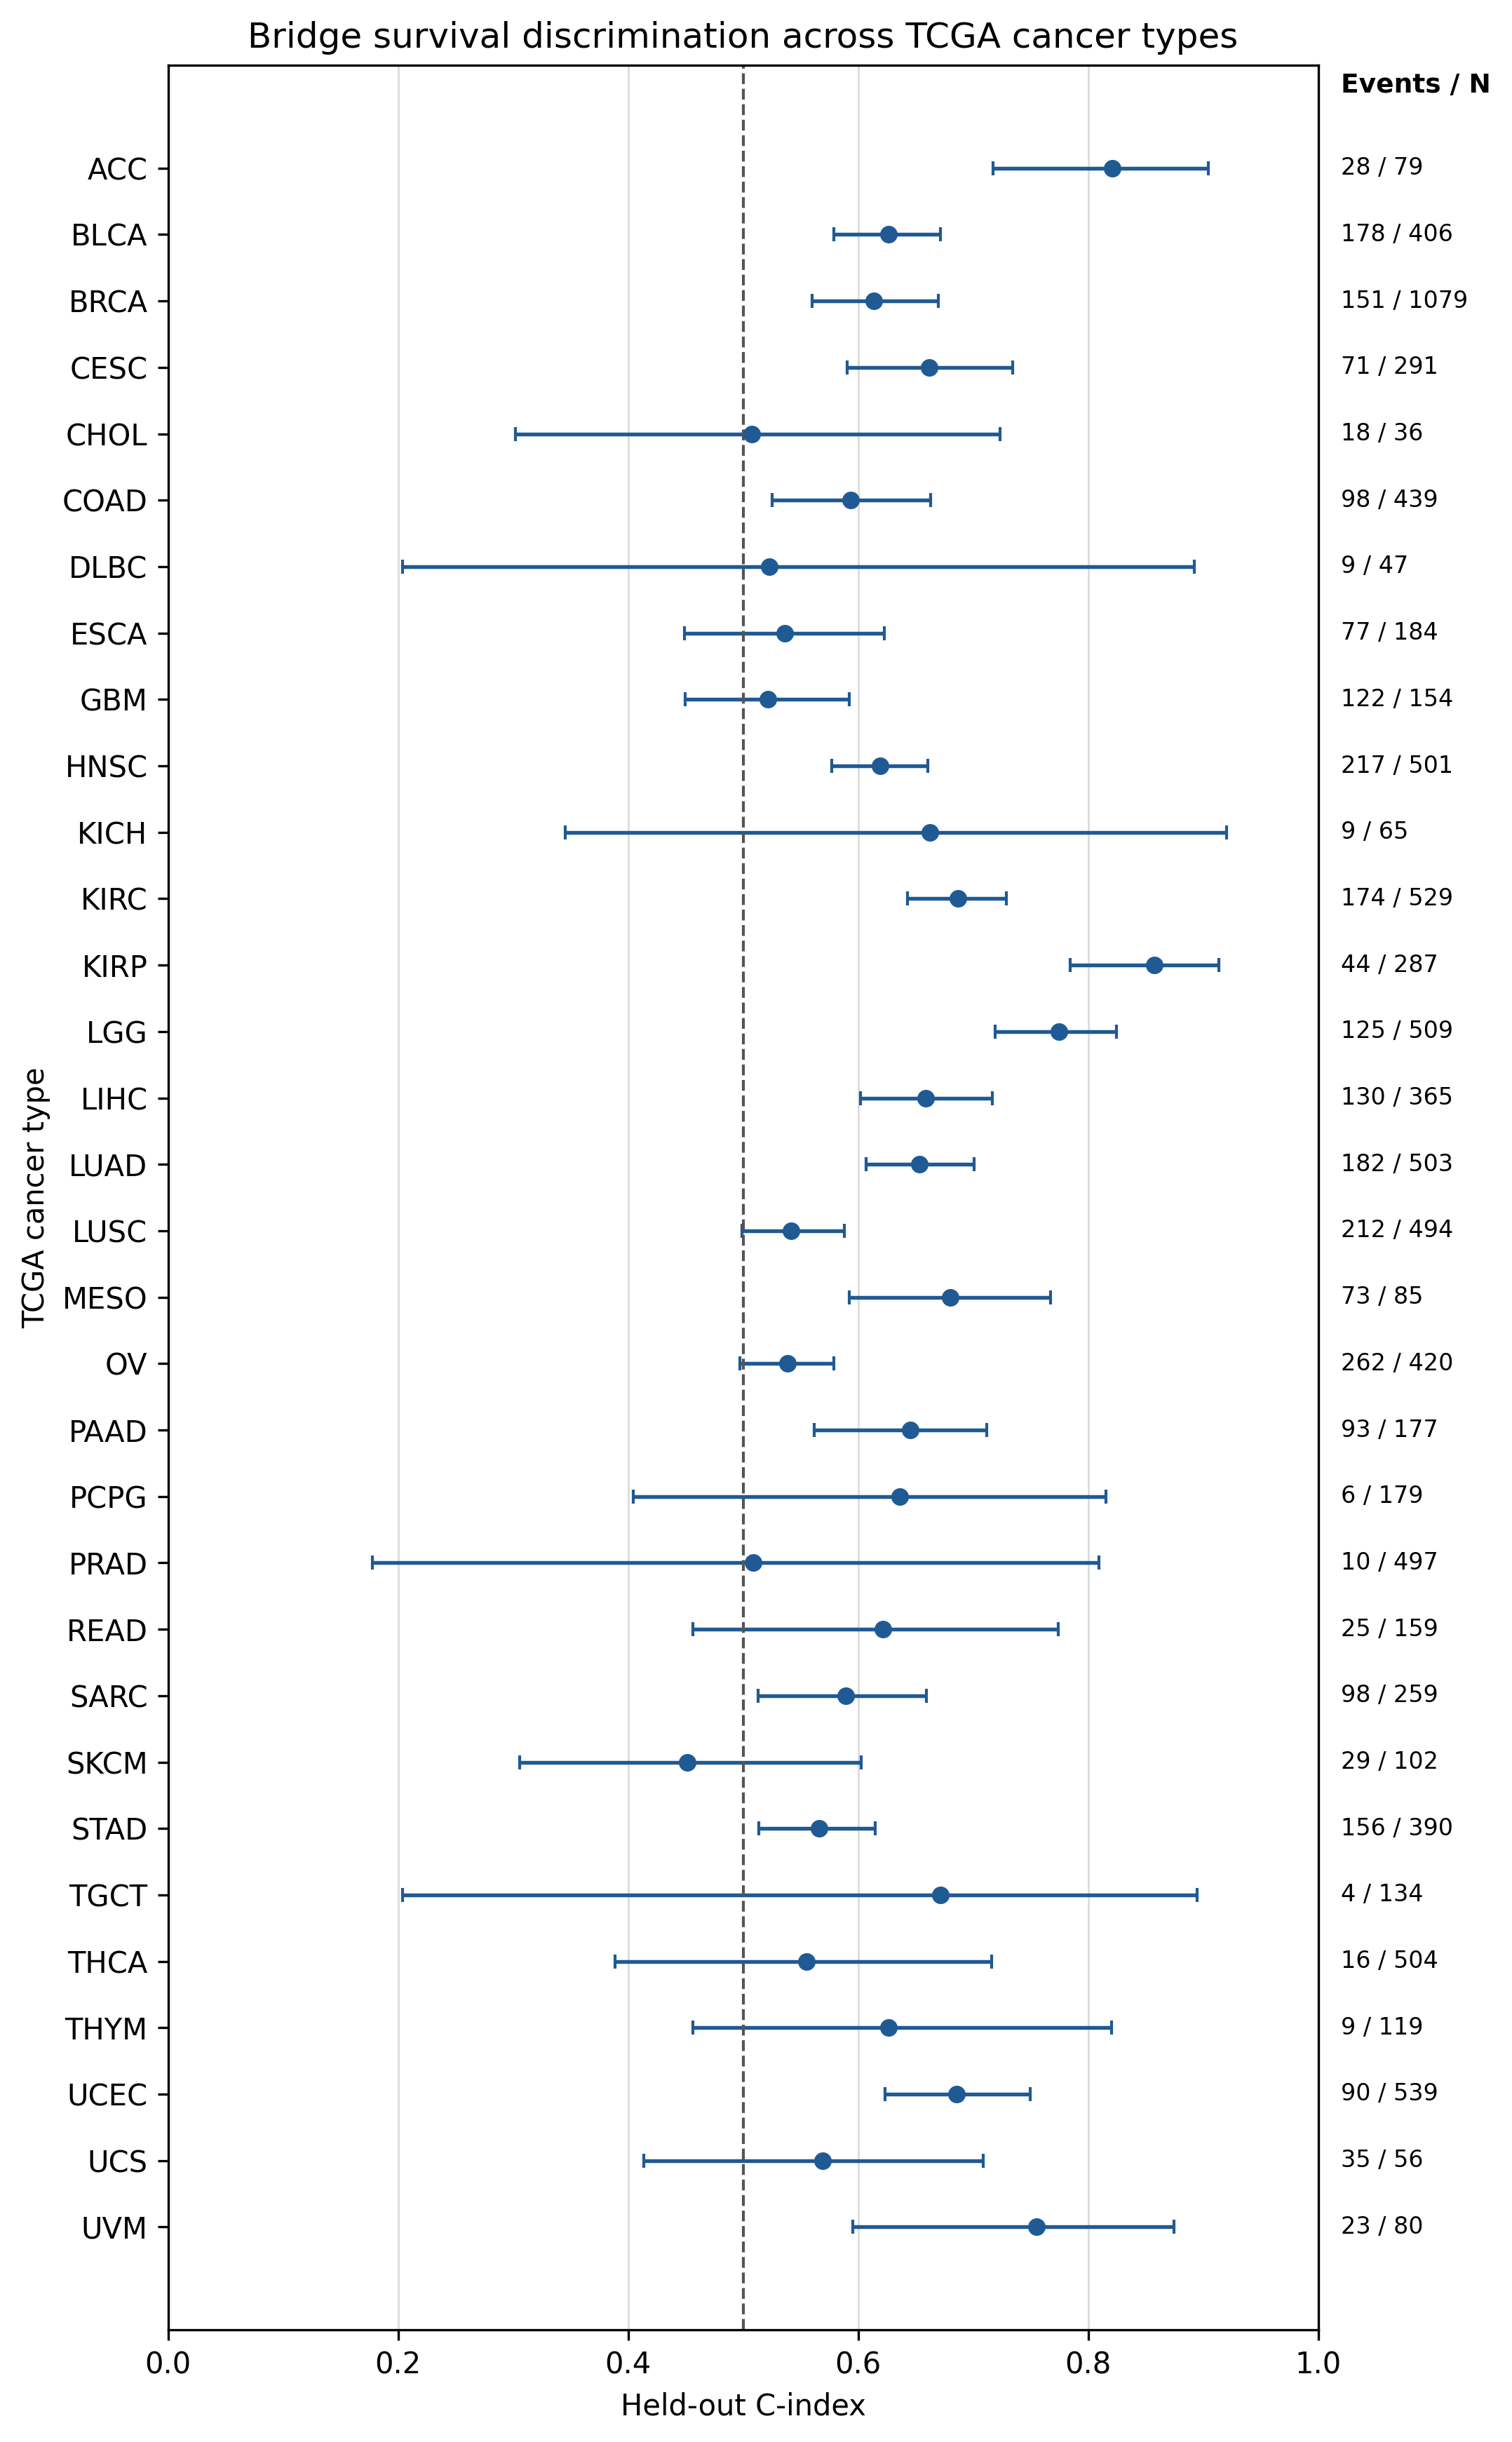

In [11]:
display(Image(filename=str(FIGURES / 'bridge_5fold_oof_per_cancer_survival_forest.png')))

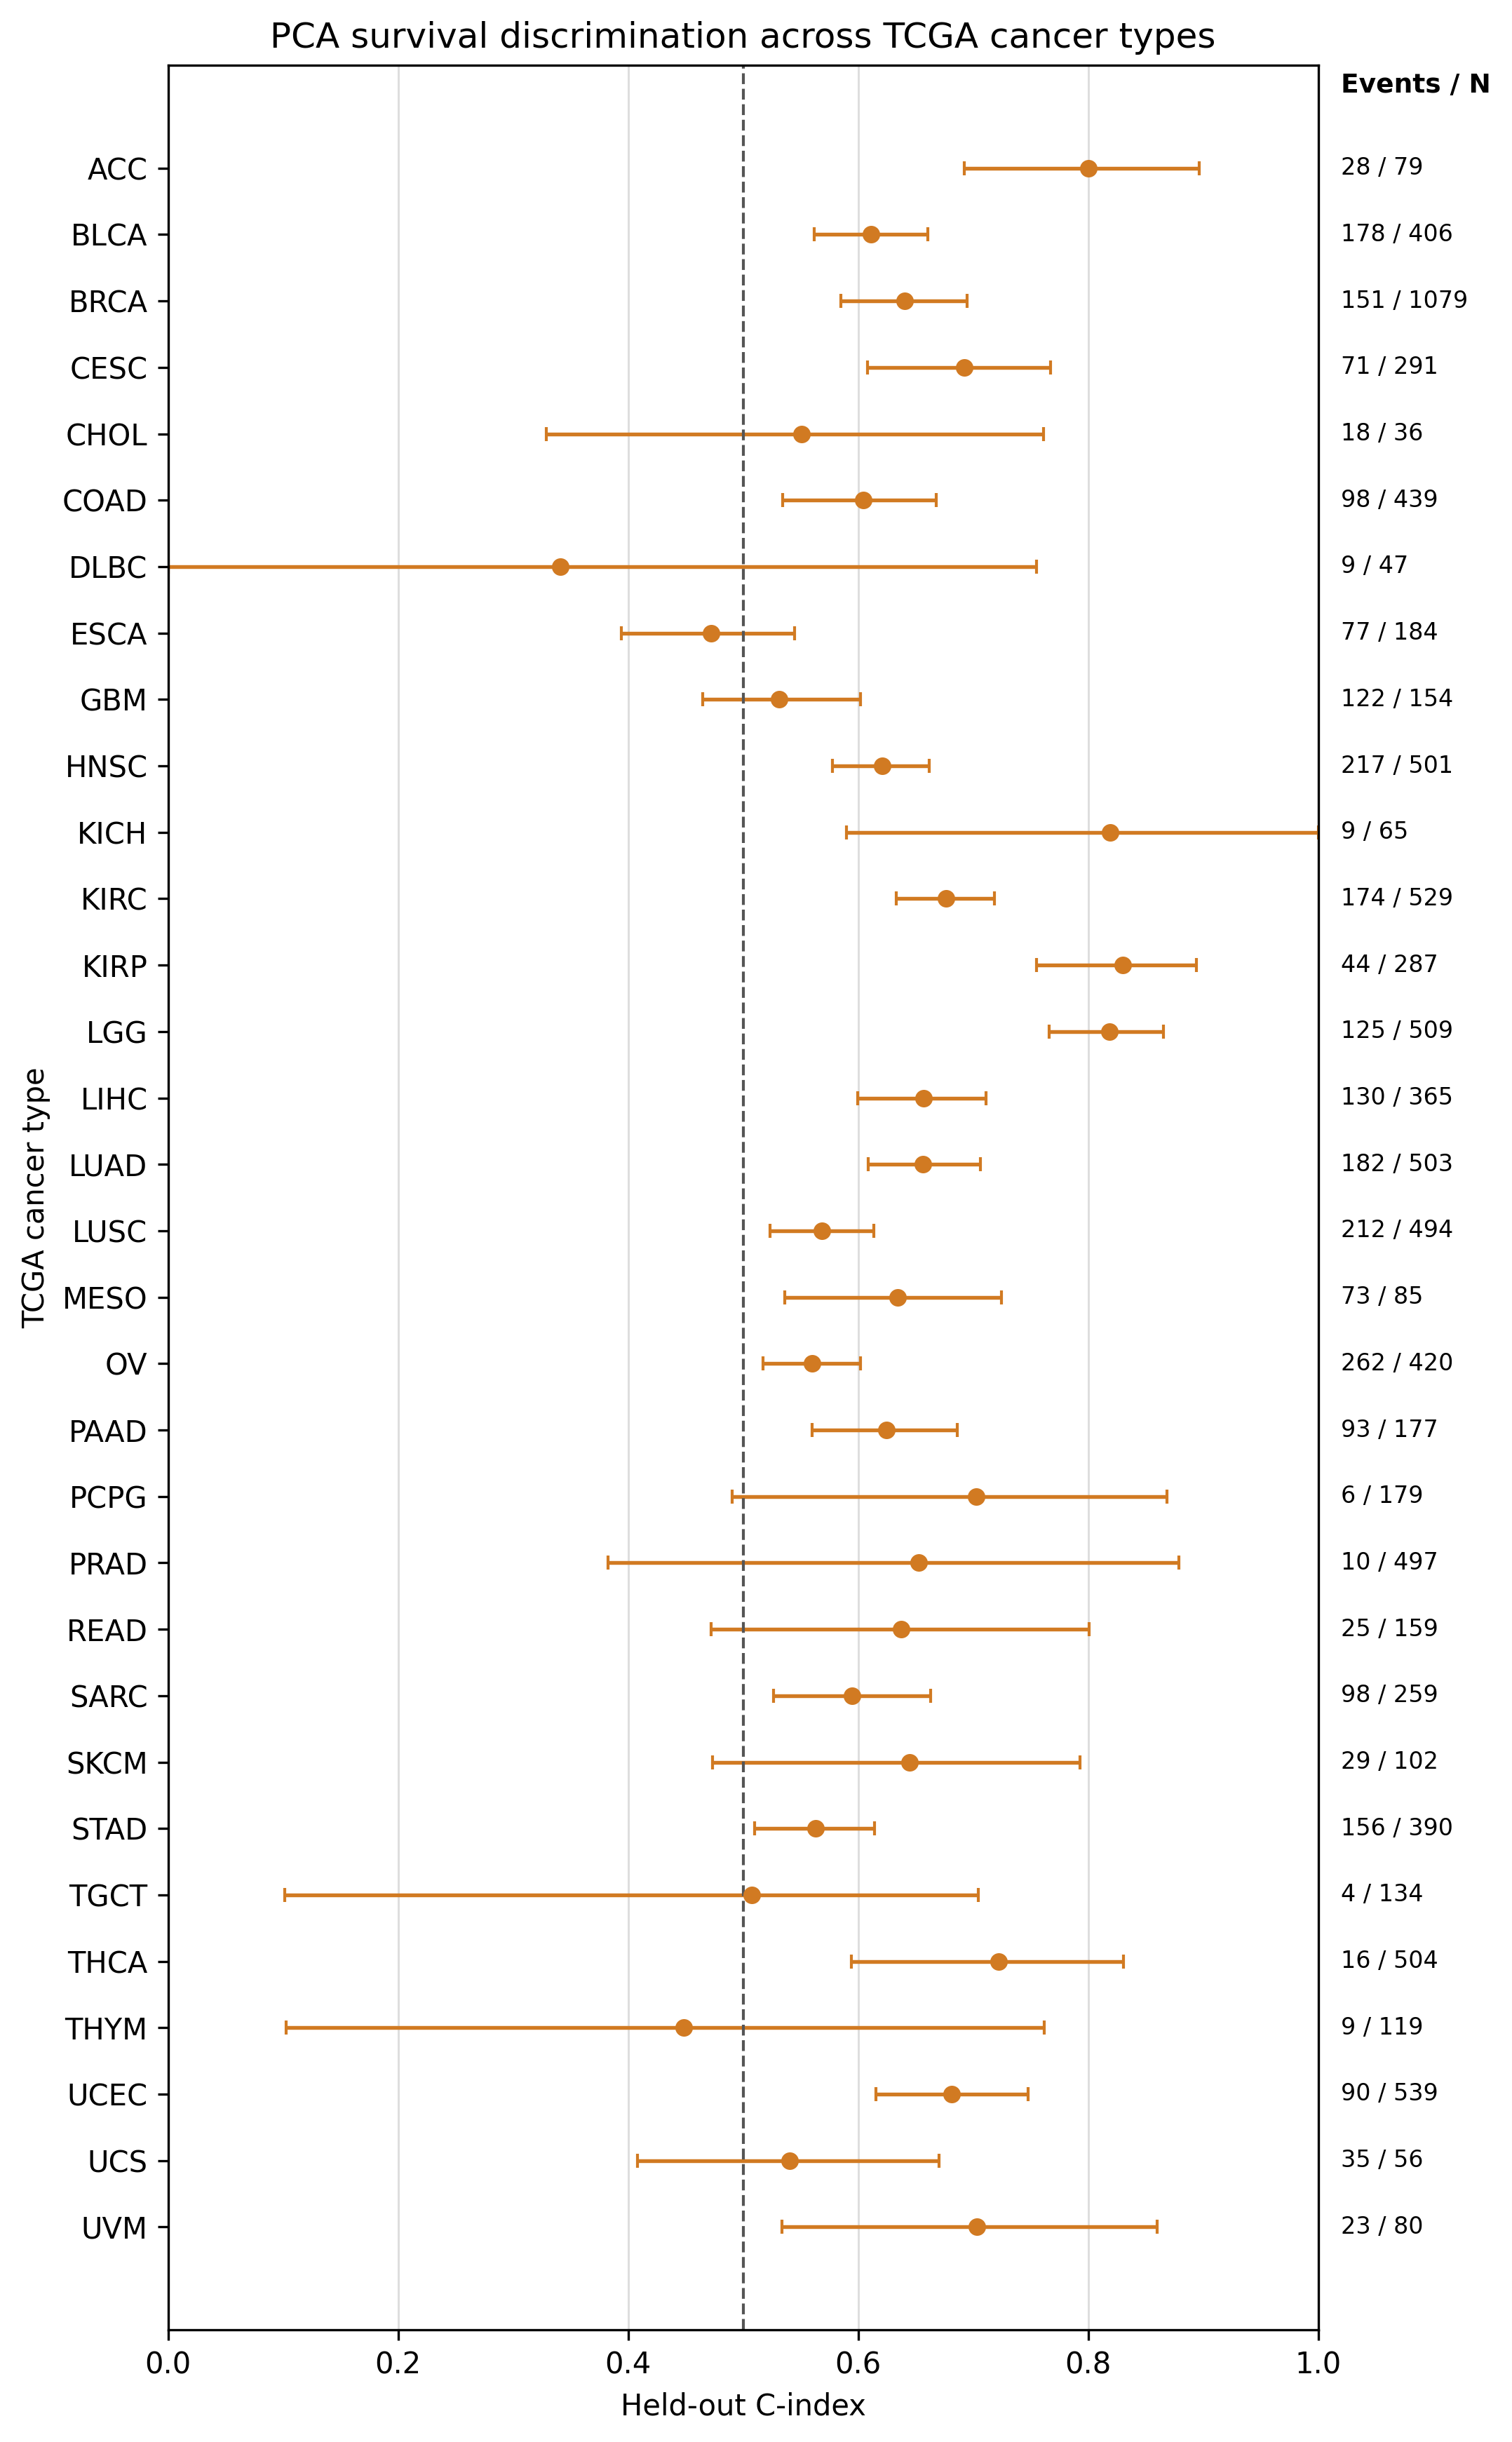

In [12]:
display(Image(filename=str(FIGURES / 'pca128_5fold_oof_per_cancer_survival_forest.png')))

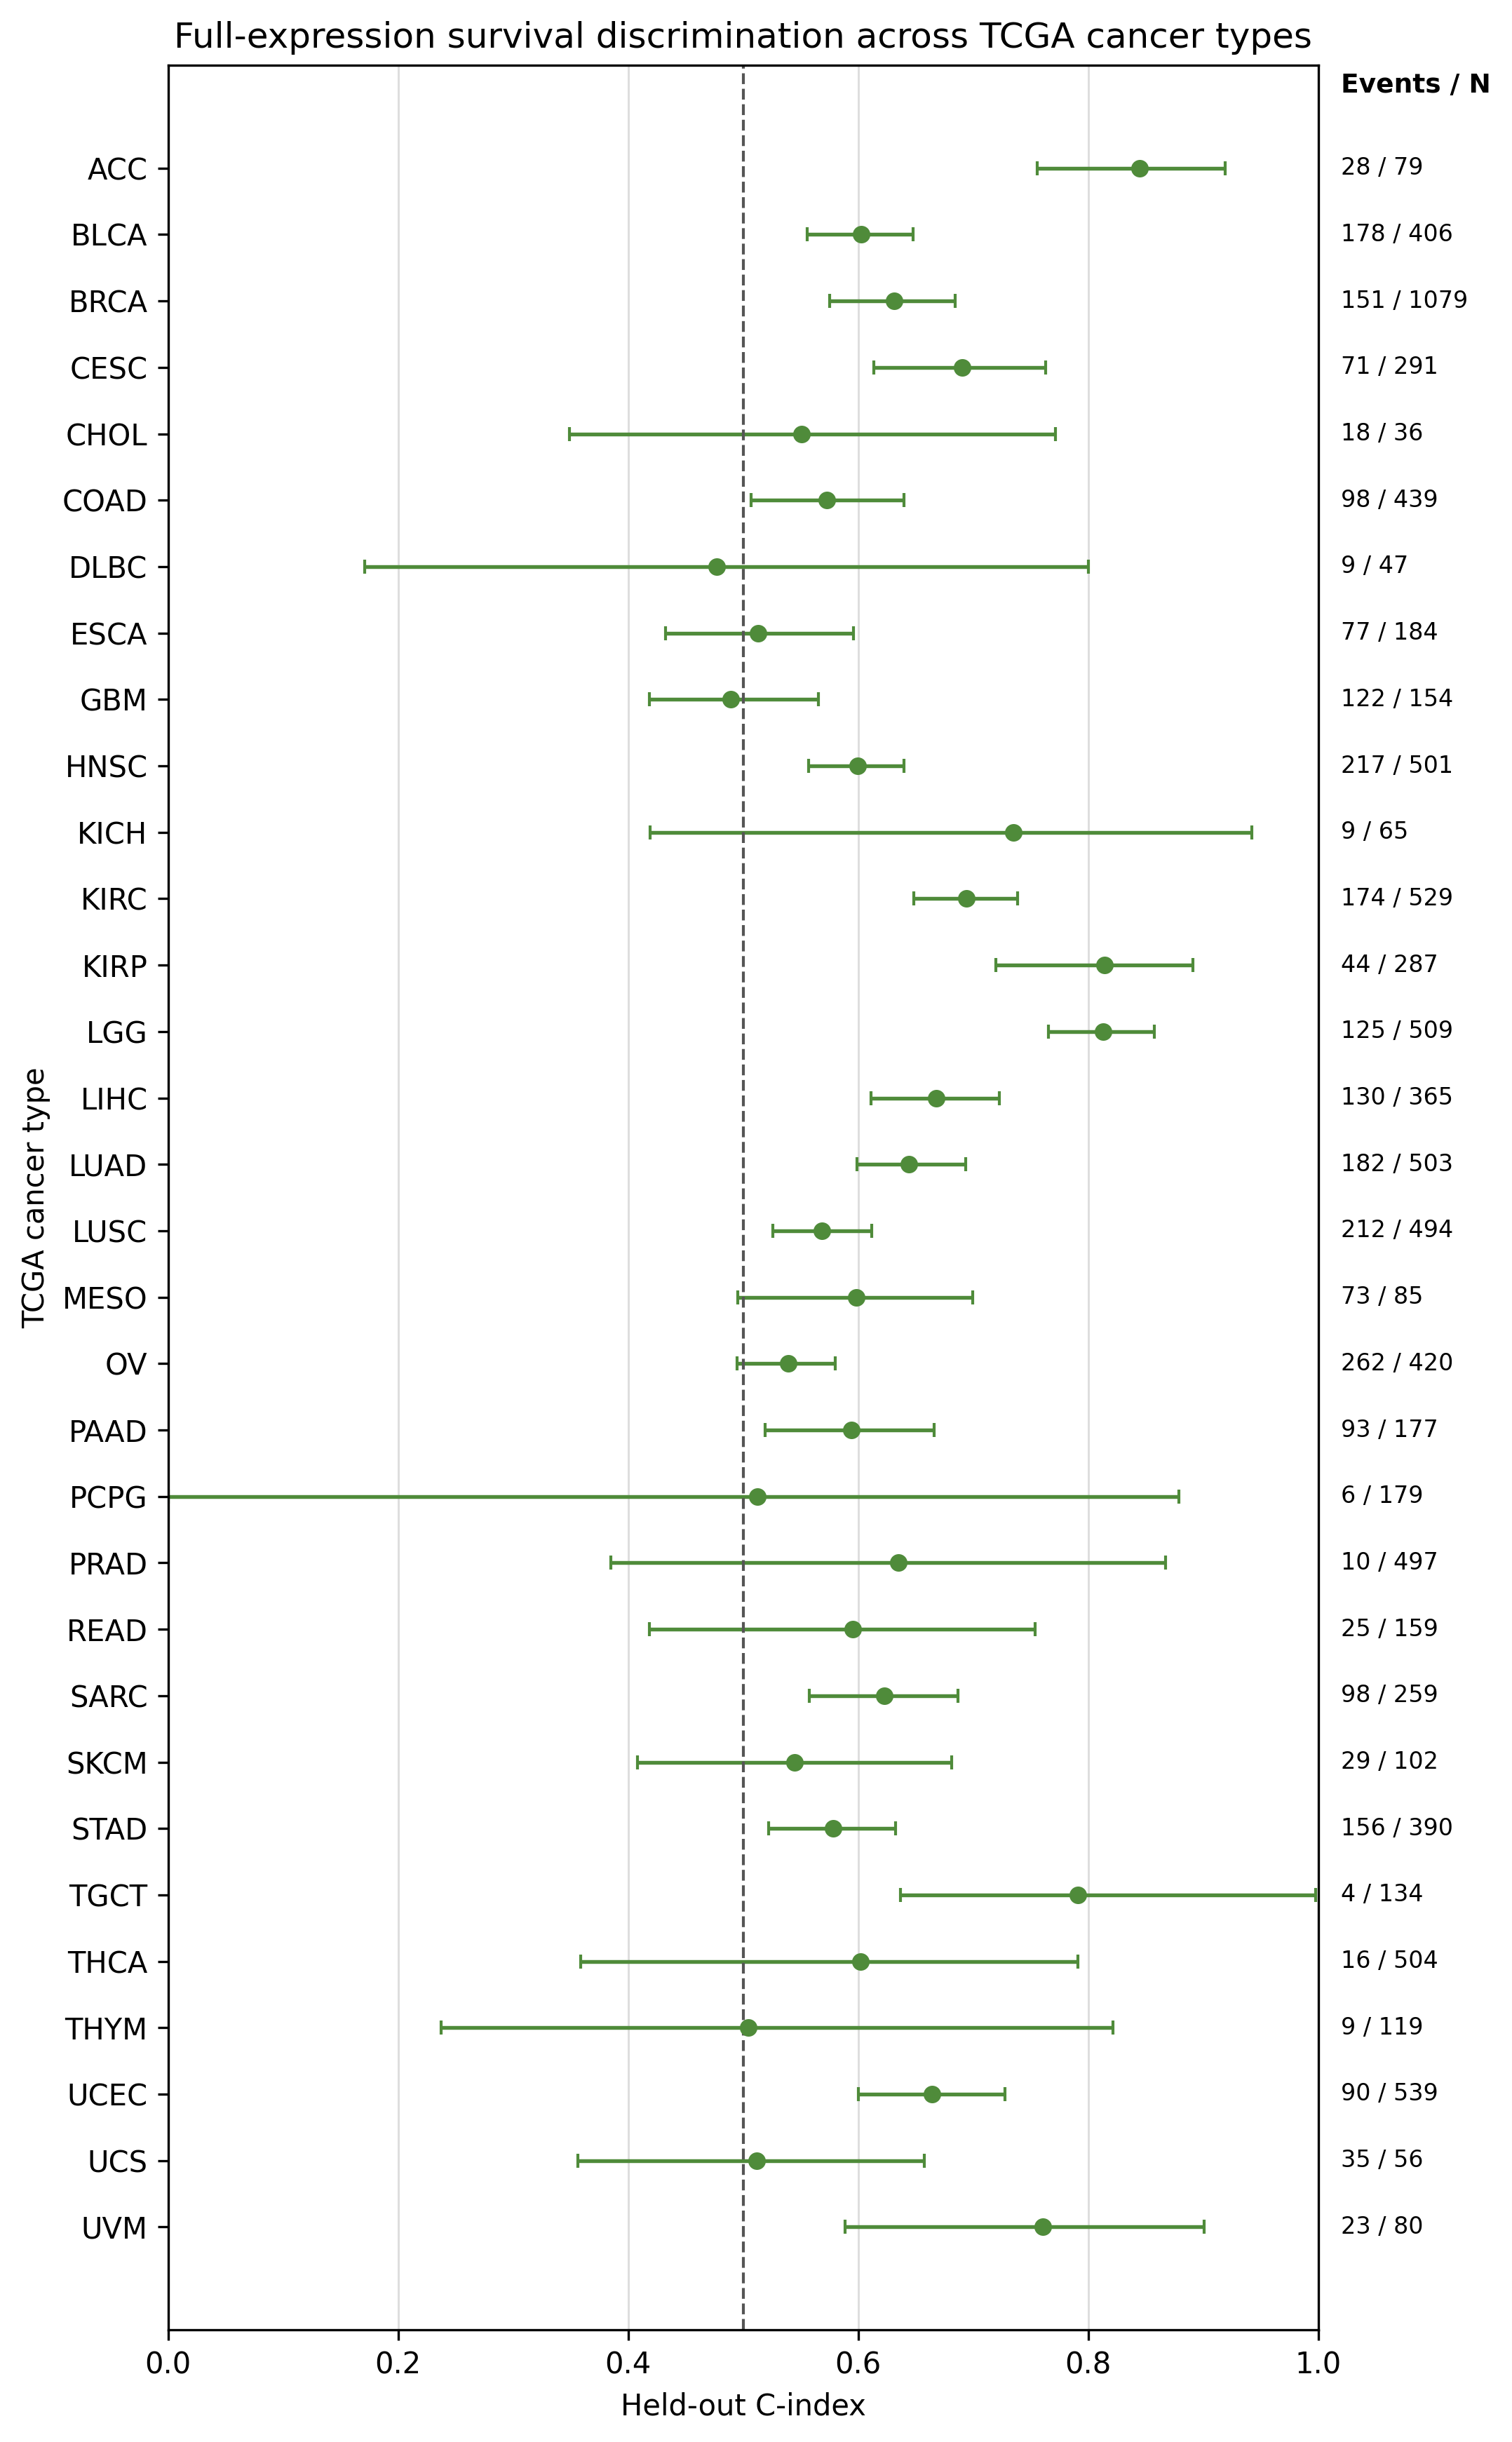

In [13]:
display(Image(filename=str(FIGURES / 'raw_expression_5fold_oof_per_cancer_survival_forest.png')))

### Direct representation comparisons

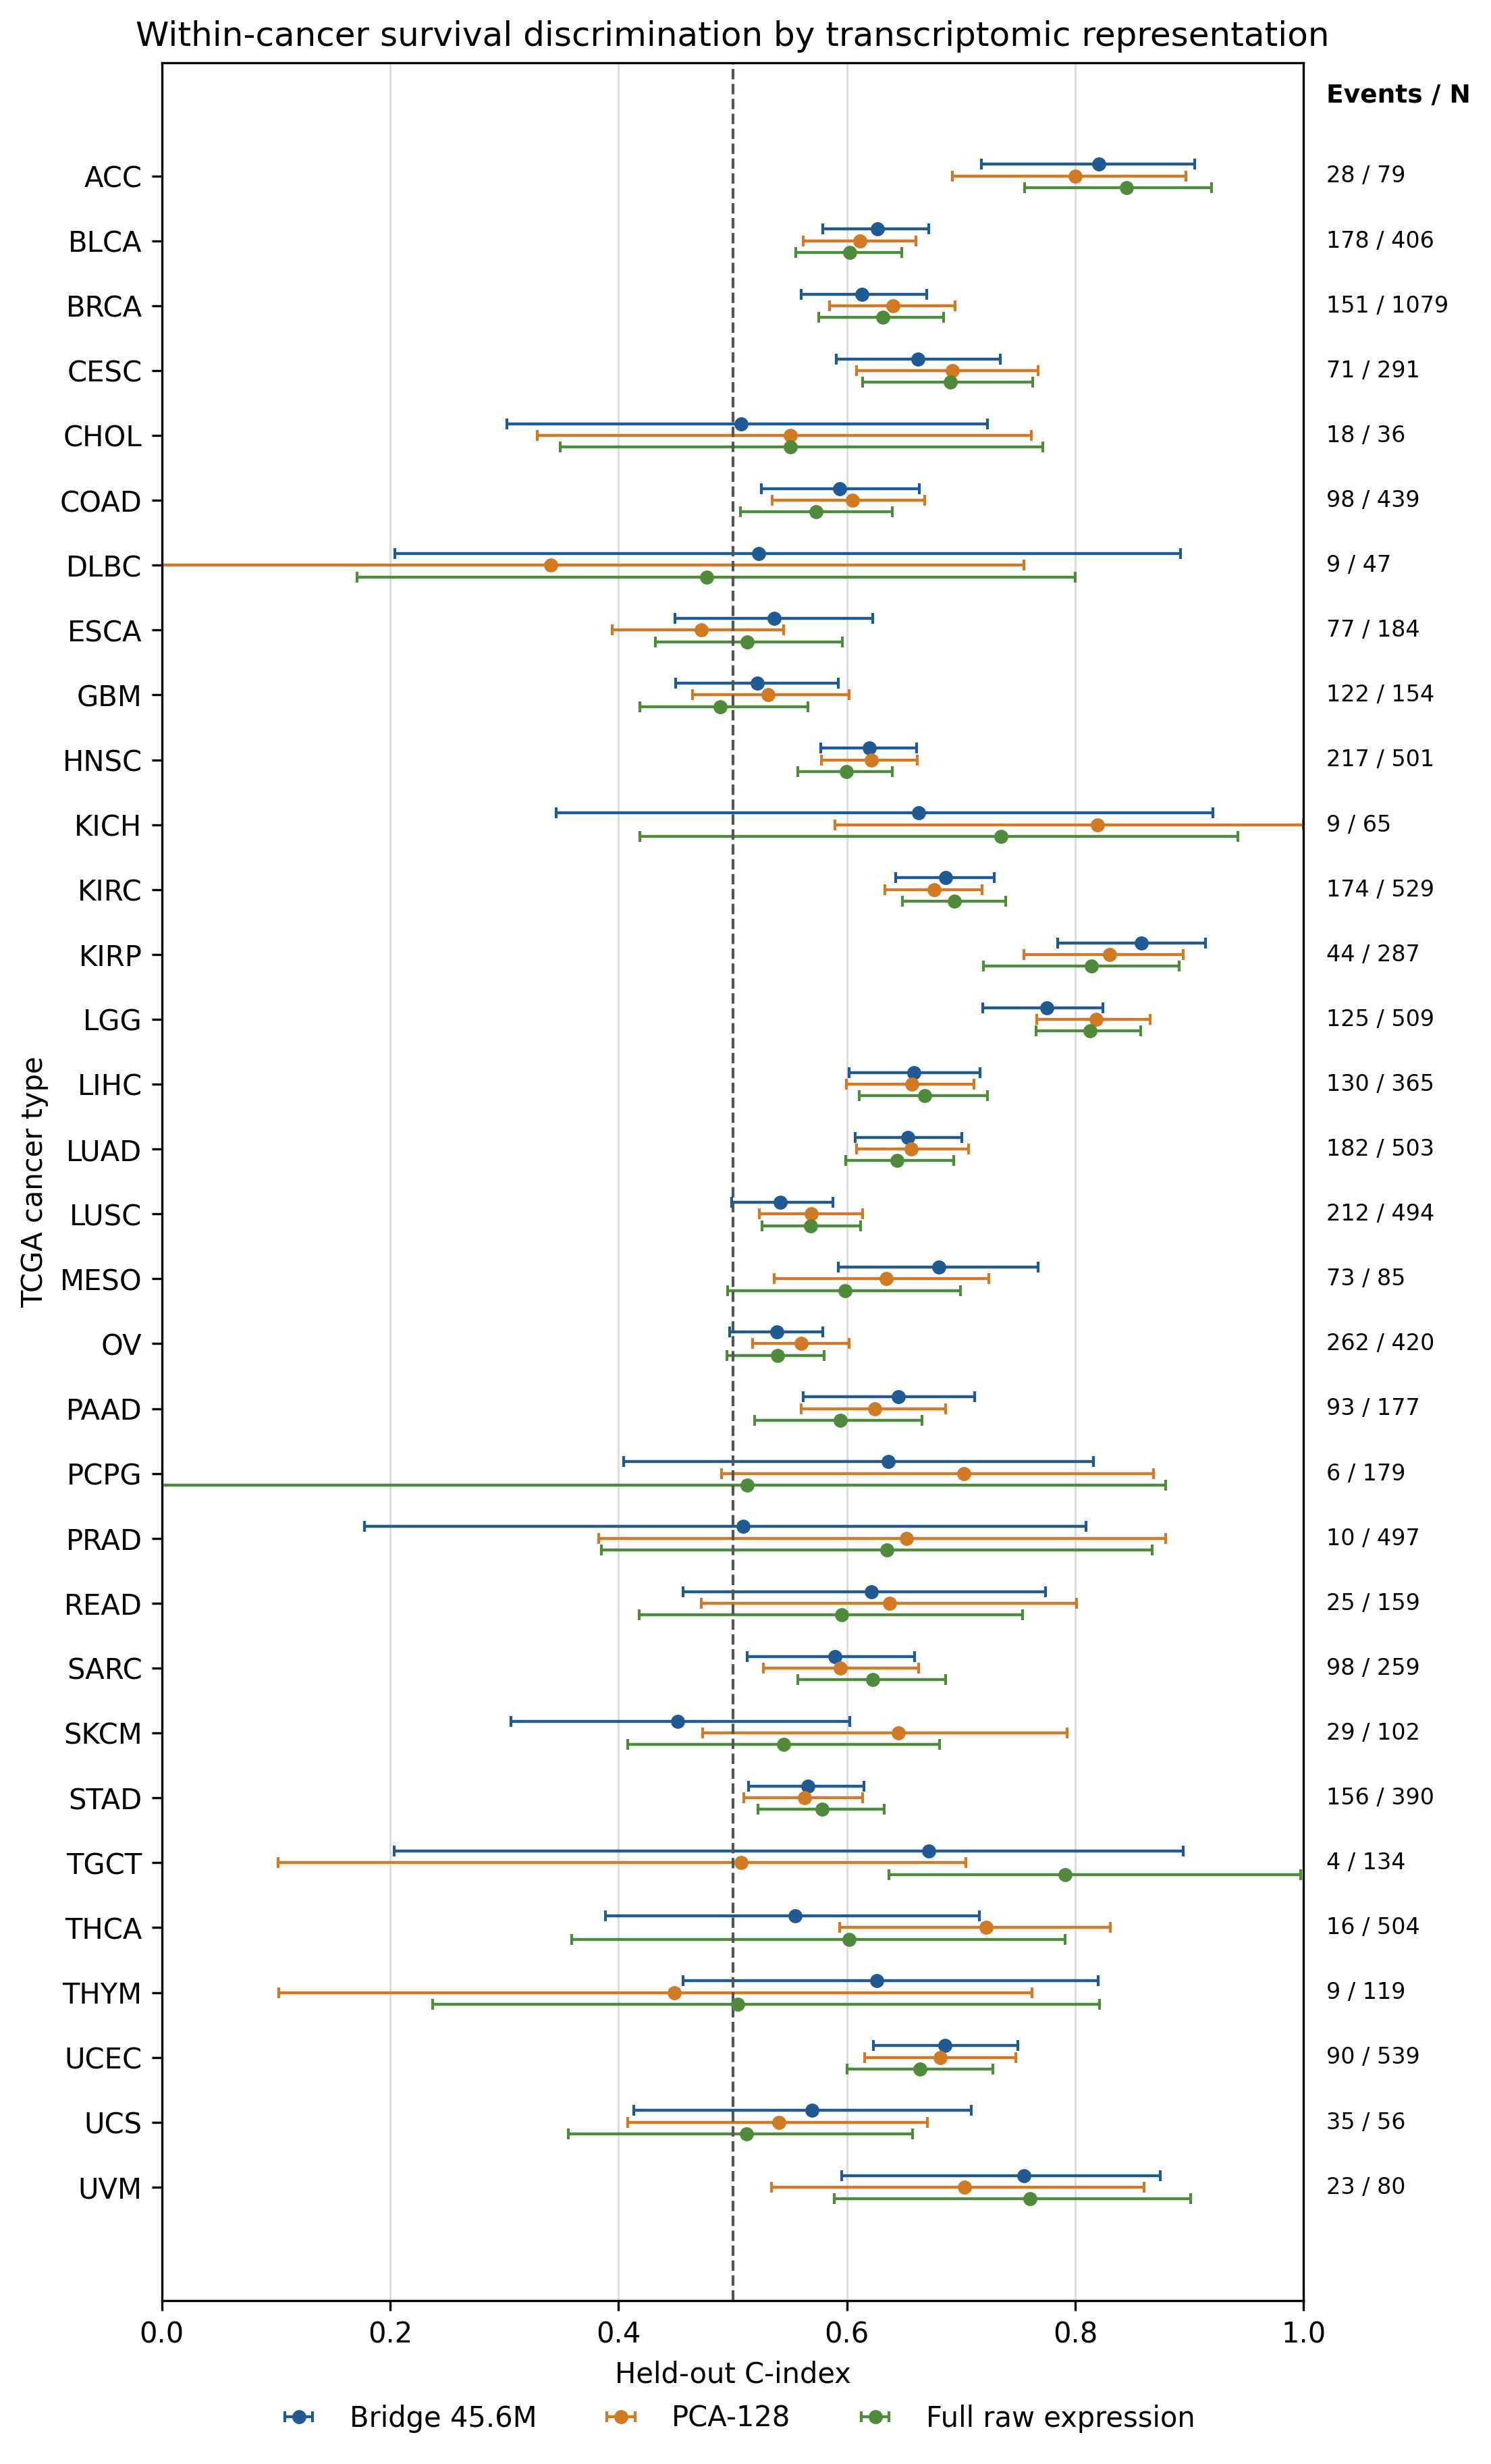

In [14]:
display(Image(filename=str(FIGURES / 'bridge_pca_raw_5fold_oof_survival_forest.png')))

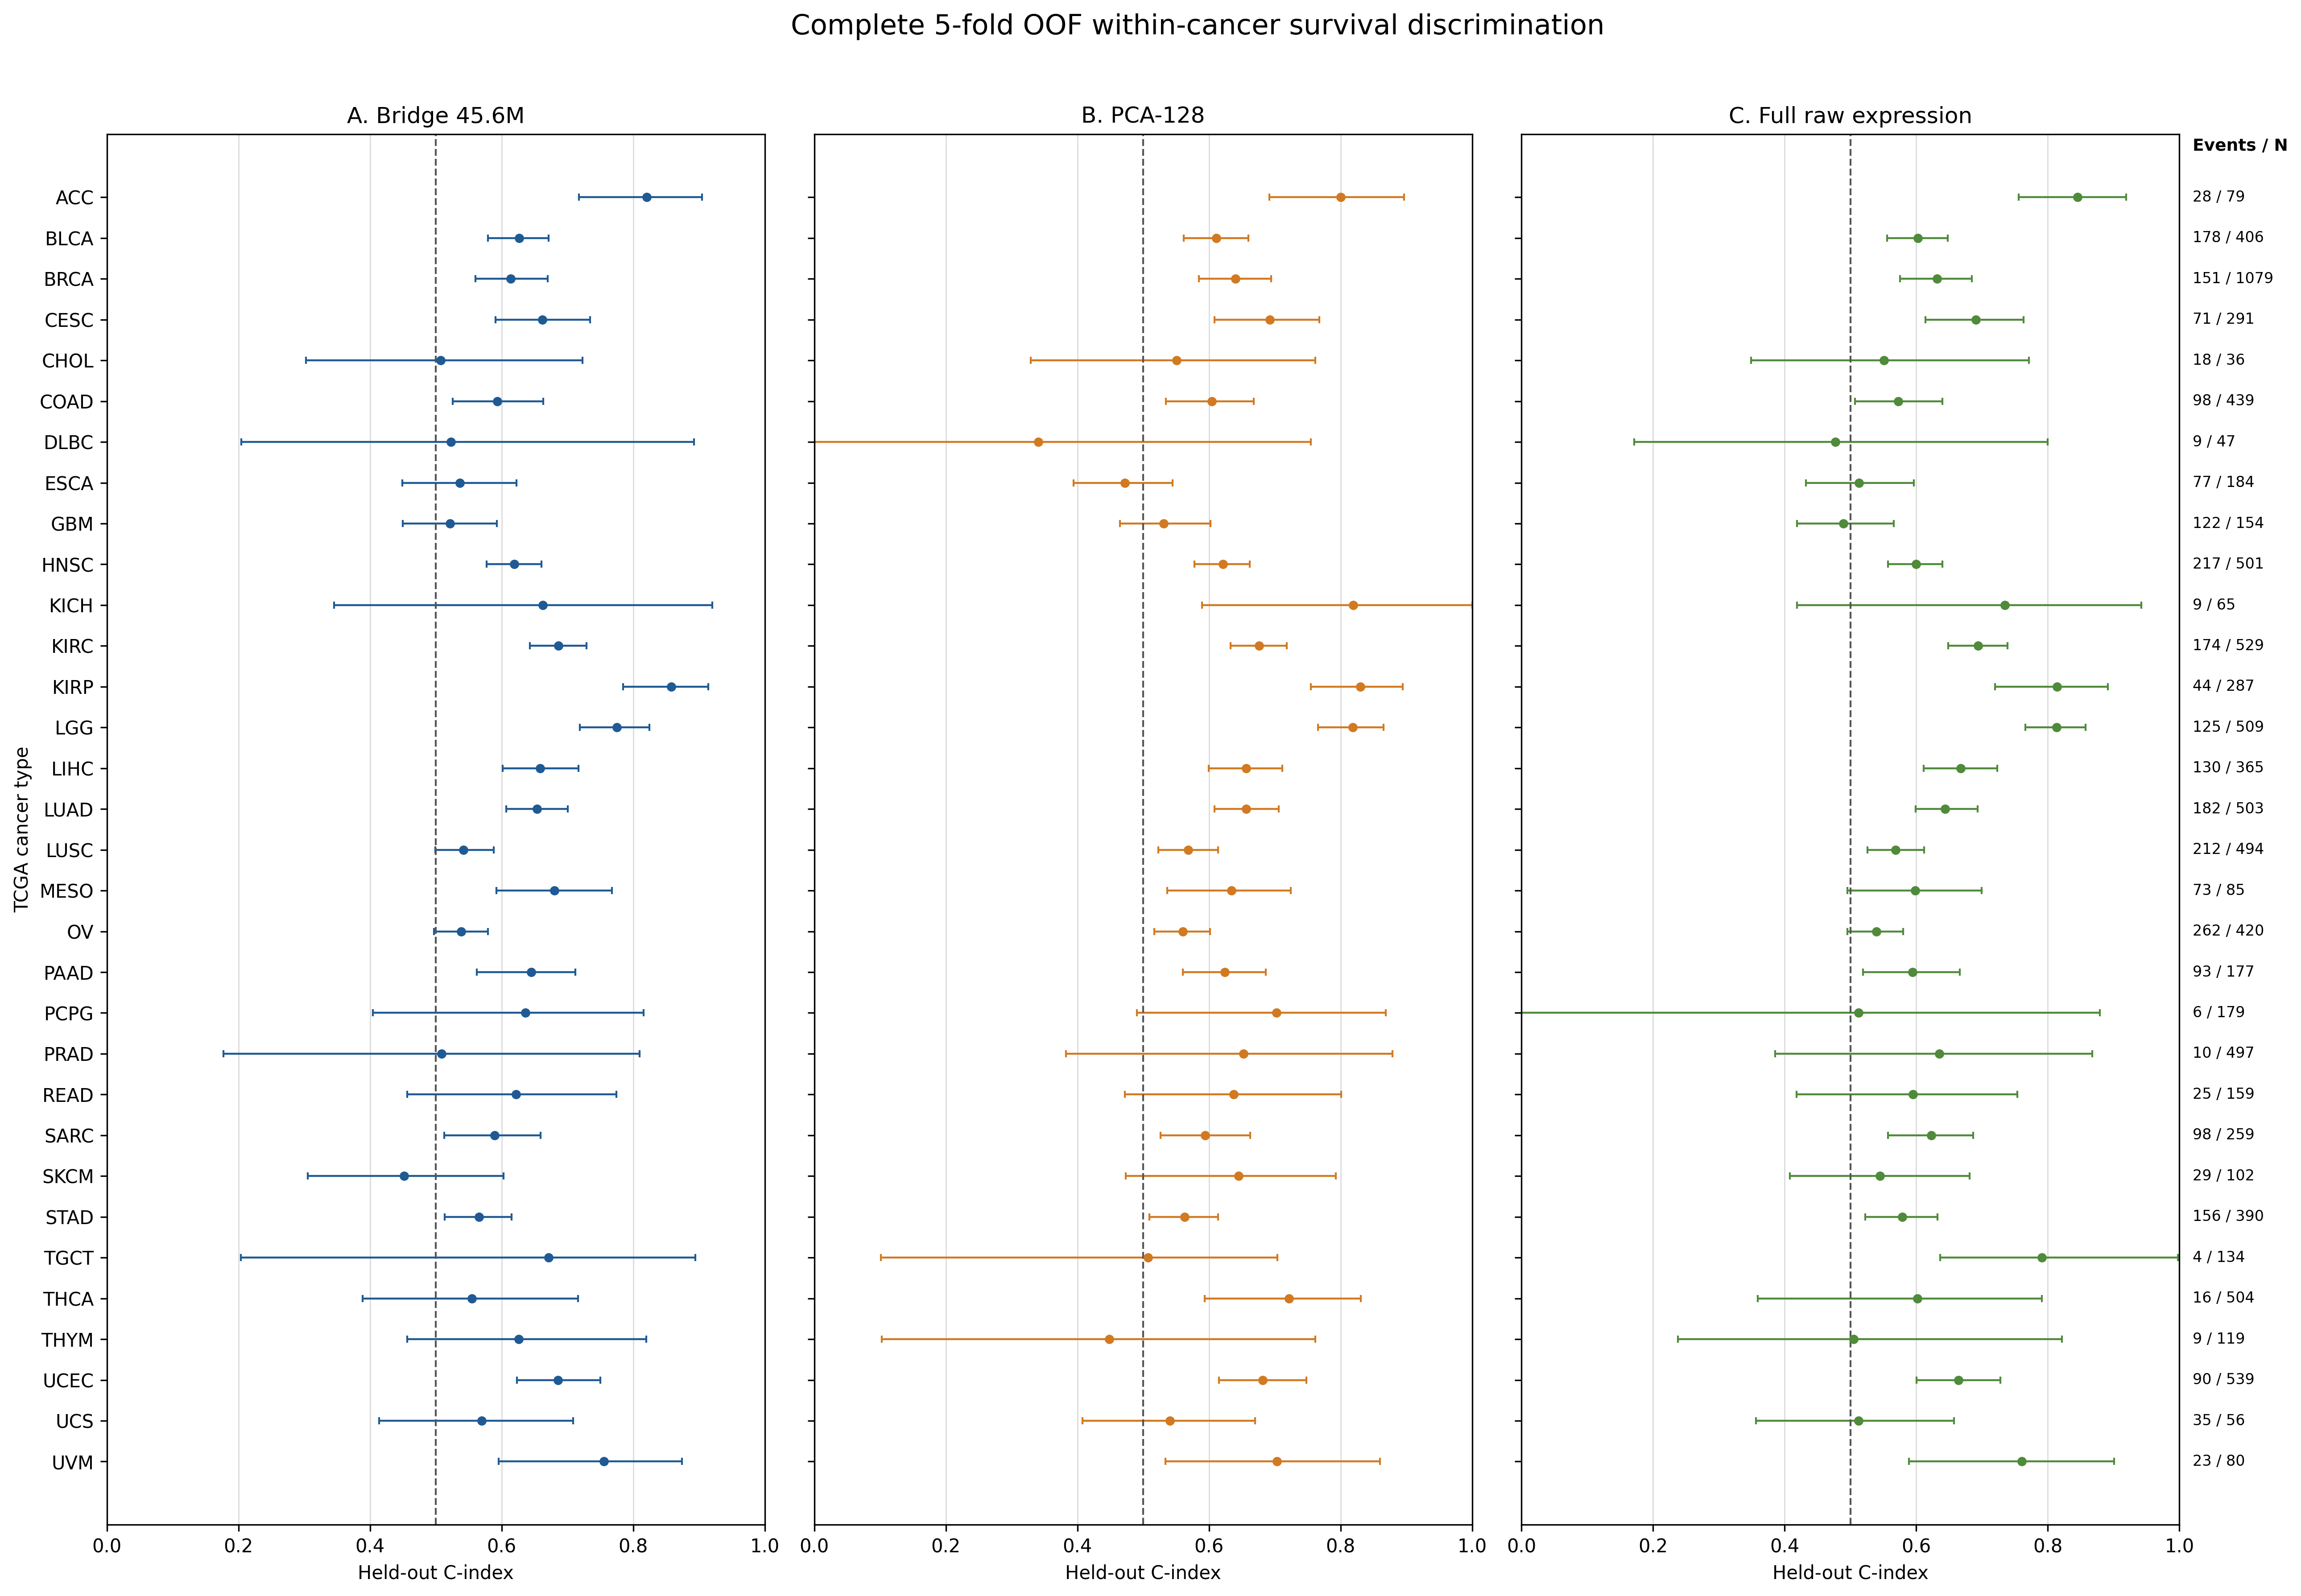

In [15]:
display(Image(filename=str(FIGURES / 'bridge_pca_raw_5fold_oof_survival_three_panel.png')))

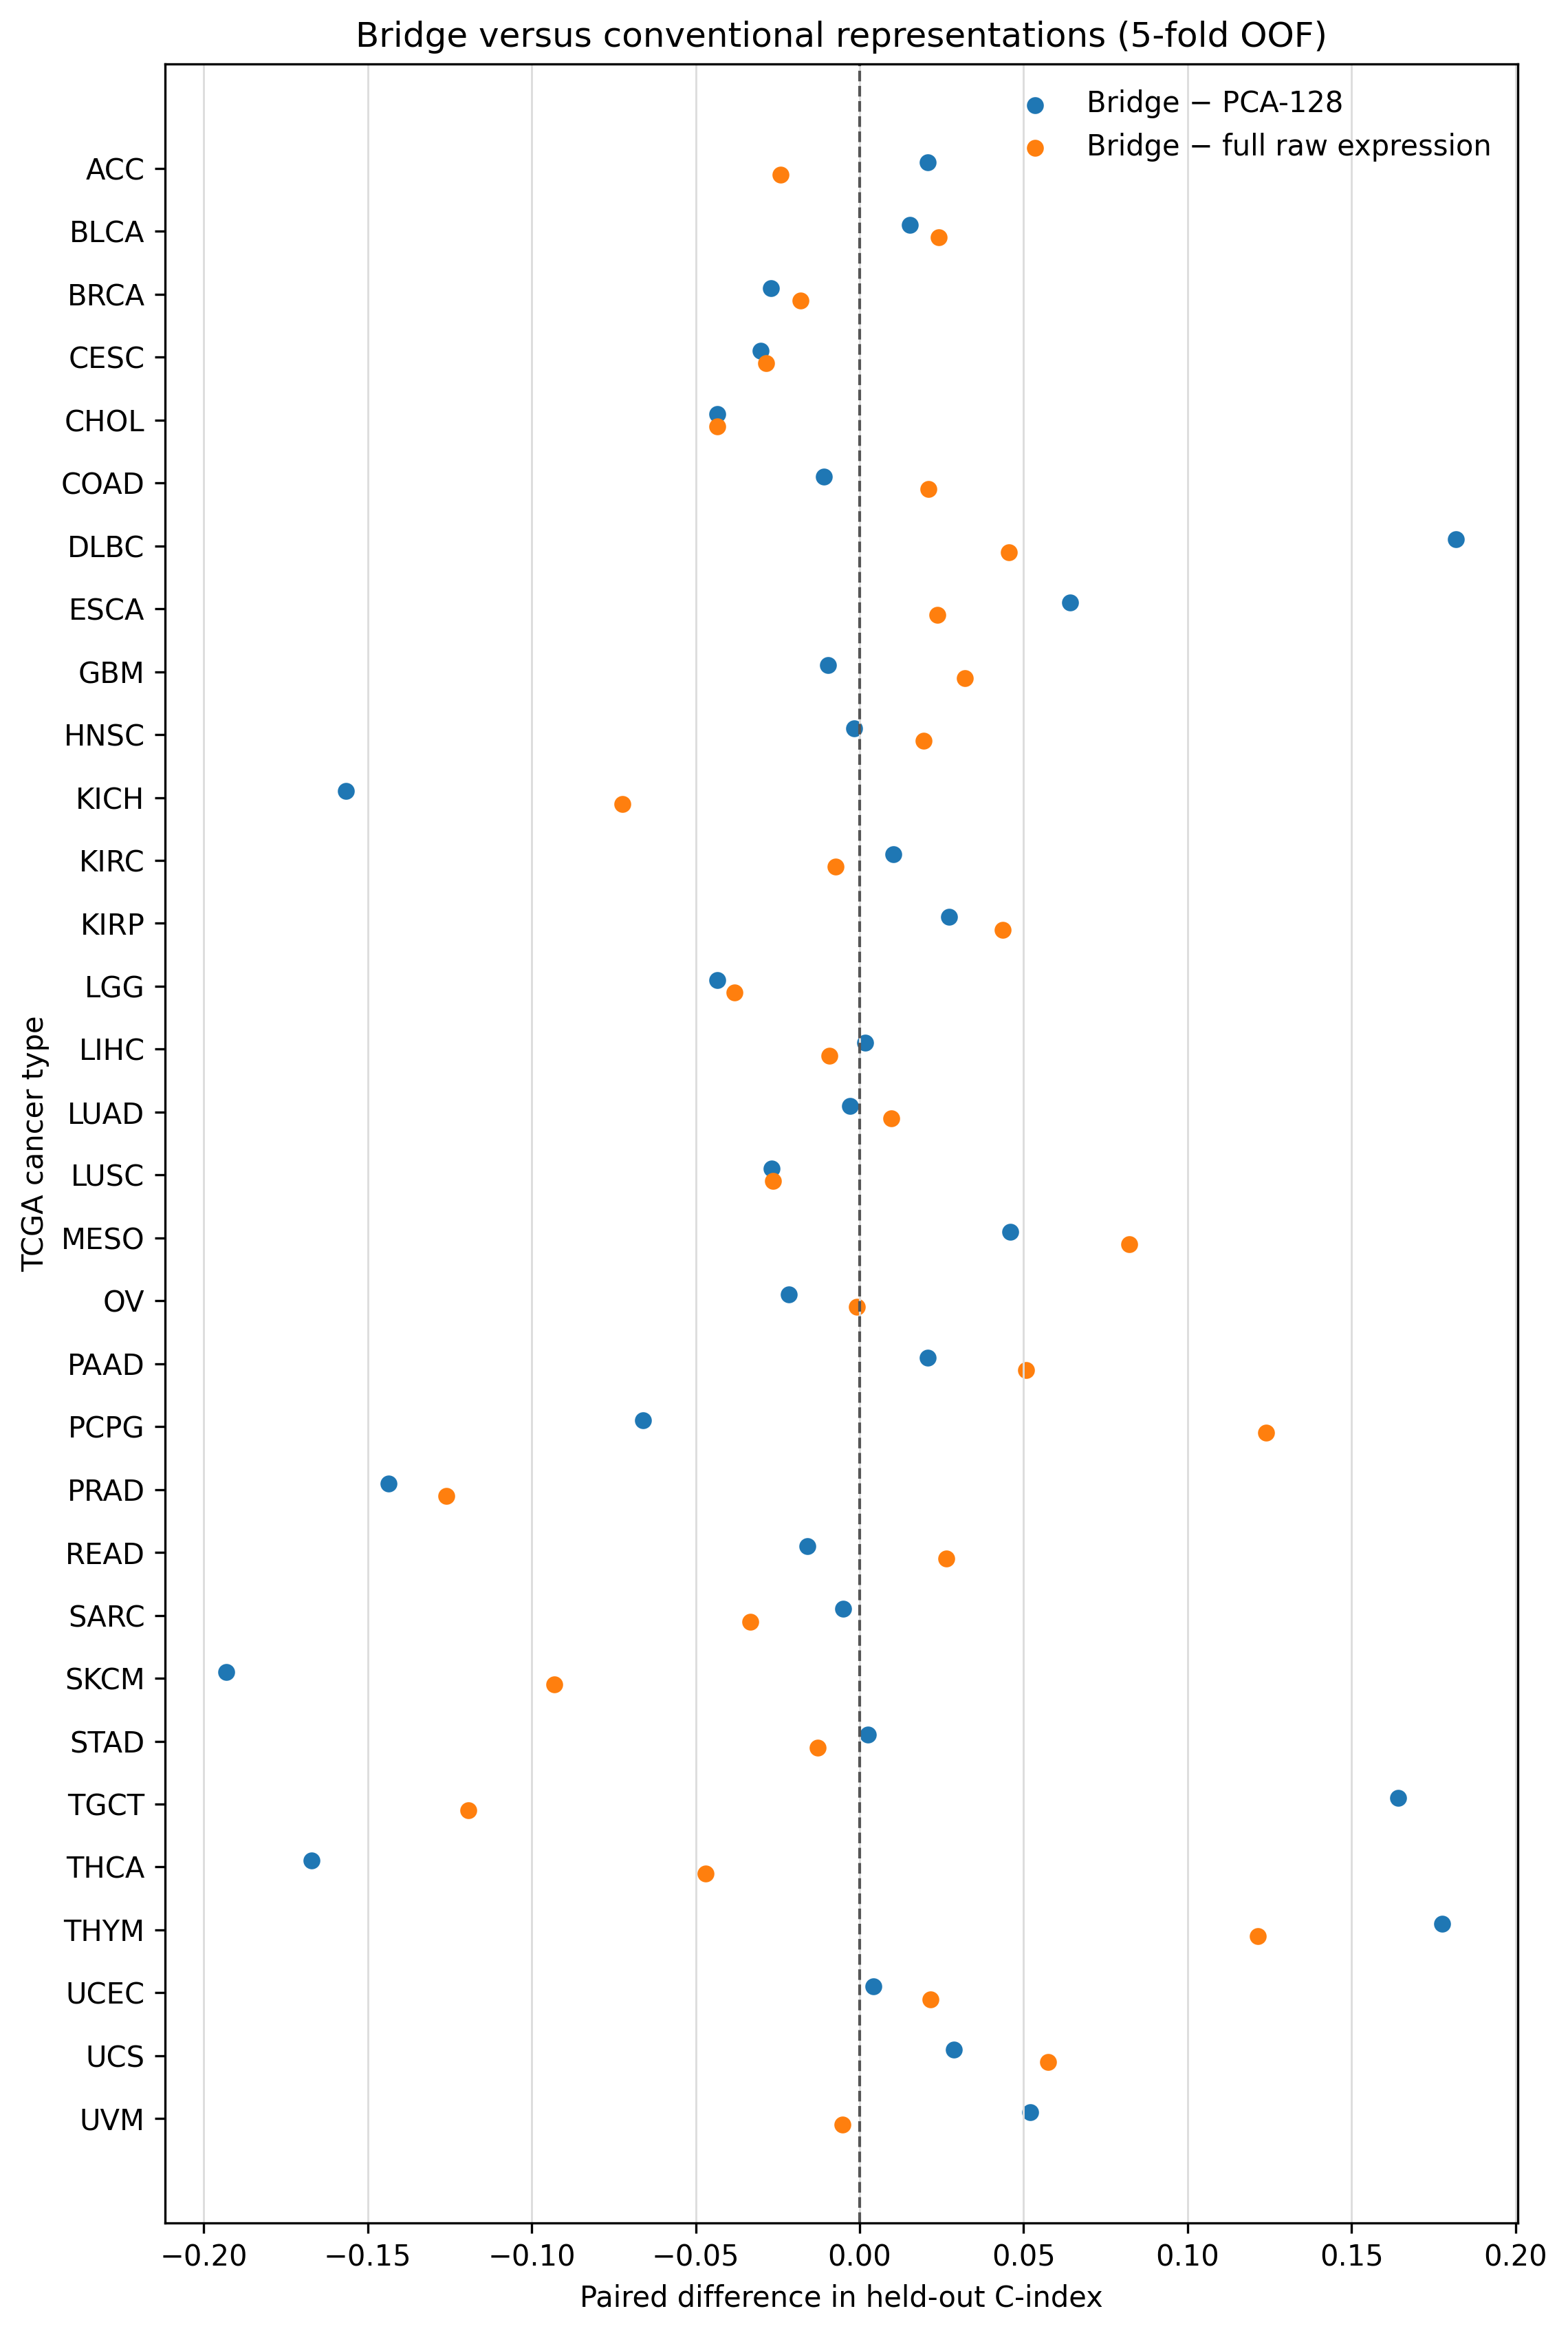

In [16]:
display(Image(filename=str(FIGURES / 'bridge_vs_conventional_5fold_oof_delta_cindex.png')))

In [17]:
oof_comparison = pd.read_csv('results/survival_5fold_oof_representation_comparison.csv')
display(oof_comparison.style.format({column: '{:.3f}' for column in oof_comparison.columns
                                     if 'index' in column.lower() or 'CI' in column or '−' in column})
        .hide(axis='index'))

cancer,N,events,Bridge C-index,raw C-index,PCA C-index,Bridge CI low,raw CI low,PCA CI low,Bridge CI high,raw CI high,PCA CI high,Bridge − PCA,Bridge − raw
ACC,79,28,0.821,0.845,0.800,0.718,0.755,0.692,0.905,0.919,0.897,0.021,-0.024
BLCA,406,178,0.627,0.603,0.611,0.579,0.555,0.562,0.671,0.648,0.660,0.015,0.024
BRCA,1079,151,0.613,0.631,0.640,0.560,0.575,0.585,0.670,0.685,0.695,-0.027,-0.018
CESC,291,71,0.662,0.690,0.692,0.590,0.614,0.608,0.734,0.763,0.768,-0.030,-0.028
CHOL,36,18,0.507,0.551,0.551,0.302,0.349,0.329,0.723,0.771,0.761,-0.043,-0.043
COAD,439,98,0.594,0.573,0.605,0.525,0.507,0.534,0.663,0.640,0.668,-0.011,0.021
DLBC,47,9,0.523,0.477,0.341,0.204,0.171,0.000,0.892,0.800,0.755,0.182,0.045
ESCA,184,77,0.536,0.513,0.472,0.449,0.433,0.394,0.623,0.596,0.545,0.064,0.024
GBM,154,122,0.521,0.489,0.531,0.450,0.418,0.465,0.592,0.566,0.602,-0.010,0.032
HNSC,501,217,0.619,0.600,0.621,0.577,0.557,0.578,0.661,0.640,0.662,-0.002,0.020


### Comparison with repeated 80/20 tests

In [18]:
repeated_comparison = pd.read_csv('results/survival_5fold_oof_comparison_to_repeated_splits.csv')
bridge_repeat_comparison = repeated_comparison.query("representation == 'Bridge 45.6M'")
display(bridge_repeat_comparison[['cancer', 'n_patients_repeated', 'n_patients_oof',
    'n_events_repeated', 'n_events_oof', 'c_index_repeated', 'c_index_oof',
    'ci_width_repeated', 'ci_width_oof', 'ci_width_change']].sort_values('cancer')
    .style.format({column: '{:.3f}' for column in ['c_index_repeated', 'c_index_oof',
        'ci_width_repeated', 'ci_width_oof', 'ci_width_change']}).hide(axis='index'))

cancer,n_patients_repeated,n_patients_oof,n_events_repeated,n_events_oof,c_index_repeated,c_index_oof,ci_width_repeated,ci_width_oof,ci_width_change
ACC,54,79,23,28,0.796,0.821,0.194,0.187,-0.006
BLCA,269,406,120,178,0.616,0.627,0.110,0.092,-0.018
BRCA,726,1079,97,151,0.545,0.613,0.143,0.110,-0.033
CESC,201,291,49,71,0.685,0.662,0.175,0.144,-0.032
CHOL,23,36,12,18,0.682,0.507,0.470,0.421,-0.049
COAD,298,439,68,98,0.610,0.594,0.155,0.138,-0.017
DLBC,30,47,6,9,0.392,0.523,0.564,0.688,0.124
ESCA,130,184,53,77,0.522,0.536,0.213,0.174,-0.039
GBM,110,154,86,122,0.552,0.521,0.164,0.143,-0.021
HNSC,336,501,147,217,0.595,0.619,0.126,0.084,-0.042


In [19]:
oof_stats = pd.read_csv('results/survival_5fold_oof_statistical_summary.csv')
display(oof_stats.style.format({'value': '{:.4g}'}).hide(axis='index'))

summary,value
median_bridge_c_index,0.6239
patient_weighted_mean_bridge_c_index,0.6247
median_pca128_c_index,0.636
median_full_raw_c_index,0.6008
bridge_cancers_gt_0.5,31
bridge_ci_above_0.5,17
pca128_ci_above_0.5,21
full_raw_ci_above_0.5,18
cancers_bridge_gt_pca128,15
median_bridge_minus_pca128,-0.002364


Complete OOF coverage raises Bridge's median within-cancer C-index from 0.598 to 0.624 and narrows the median CI width from 0.179 to 0.148; 28 of 32 Bridge intervals narrow. Bridge is above chance by point estimate in 31 cancers and has a CI wholly above 0.5 in 17. KIRP, ACC, LGG, UCEC, CESC, LIHC, LUAD, and KIRC remain supported; MESO, PAAD, BLCA, BRCA, COAD, SARC, HNSC, and STAD also exclude chance.

Bridge exceeds PCA and raw expression in 15 cancers each. Median differences are small (−0.002 versus PCA and −0.003 versus raw) and neither paired sign-flip nor Wilcoxon tests indicates a systematic difference (all p > 0.73); nonsignificance is not evidence of equivalence. KICH, PCPG, PRAD, SKCM, and THYM narrow relative to the repeated-split analysis but remain uncertain. TGCT remains especially uninterpretable—only four events spread across five folds—and its interval widens. Complete coverage improves sampling uncertainty but cannot create event information absent from TCGA.

### A2.2 Legacy split-mean Cox heatmap

This heatmap reports censoring-aware C-index within each cancer on held-out patients, averaged across the same five seeded splits used by the primary Cox benchmark. `NA` indicates that a held-out cancer subset had no comparable pairs or no event. Small cohorts and low-event cancers are descriptive and can have high split-to-split variance.

In [20]:
cox_per_cancer = pd.read_csv('results/cox_mlp_per_cancer_summary.csv')
display(cox_per_cancer.sort_values(['cancer_label', 'representation'])
        [['cancer_label', 'representation', 'splits', 'test_patients_mean',
          'events_mean', 'c_index_mean', 'c_index_sd']]
        .style.format({'test_patients_mean': '{:.1f}', 'events_mean': '{:.1f}',
                       'c_index_mean': '{:.3f}', 'c_index_sd': '{:.3f}'}).hide(axis='index'))

cancer_label,representation,splits,test_patients_mean,events_mean,c_index_mean,c_index_sd
ACC,bulkformer_147m,5,16.0,7.4,0.862,0.064
ACC,bulkformer_50m,5,16.0,7.4,0.801,0.066
ACC,full_expression_25150,5,16.0,7.4,0.829,0.113
ACC,ours_45.6m,5,16.0,7.4,0.809,0.096
BLCA,bulkformer_147m,5,81.0,36.2,0.637,0.040
BLCA,bulkformer_50m,5,81.0,36.2,0.633,0.019
BLCA,full_expression_25150,5,81.0,36.2,0.649,0.042
BLCA,ours_45.6m,5,81.0,36.2,0.616,0.021
BRCA,bulkformer_147m,5,216.0,30.6,0.541,0.071
BRCA,bulkformer_50m,5,216.0,30.6,0.559,0.058


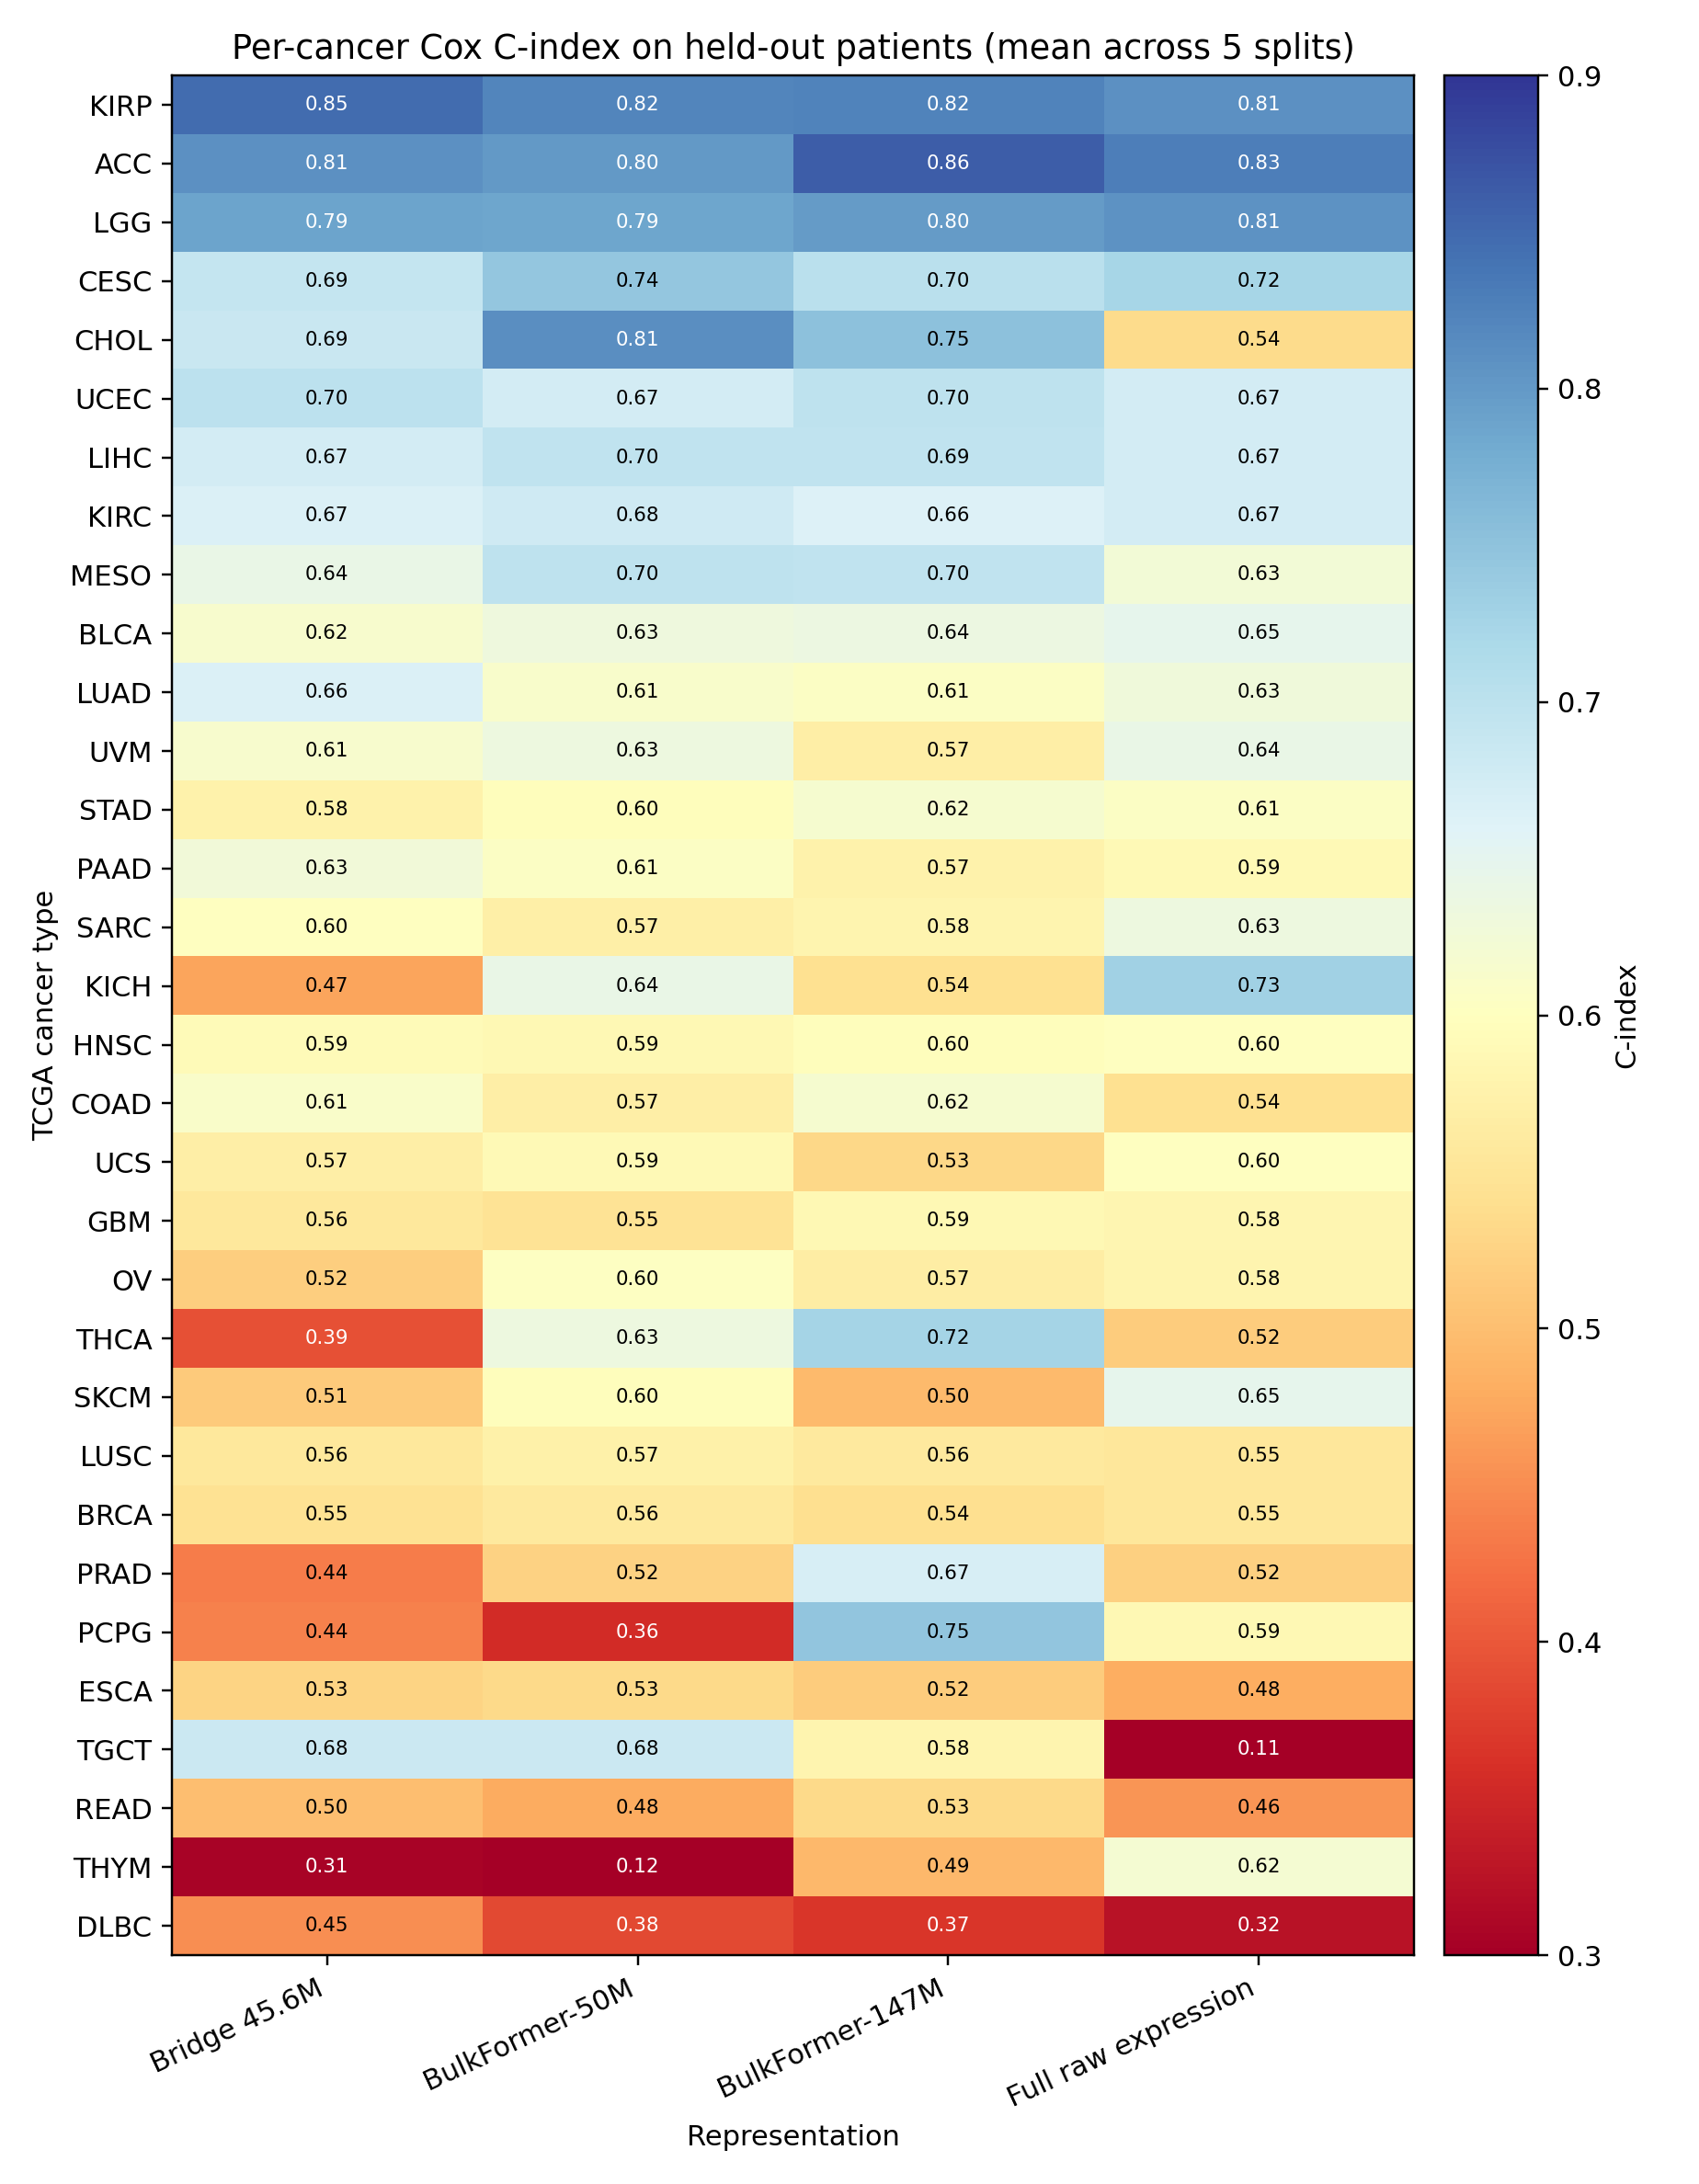

In [21]:
from IPython.display import Image
display(Image(filename=str(FIGURES / 'cox_mlp_per_cancer_c_index.png')))

### A2.3 Legacy Bridge split-SD bar chart

The bar chart isolates Bridge 45.6M and shows the mean held-out within-cancer C-index with SD across the five fixed splits. The dashed line marks chance concordance at 0.5. Large error bars primarily reflect small held-out event counts, so the cancer-specific values should be interpreted descriptively.

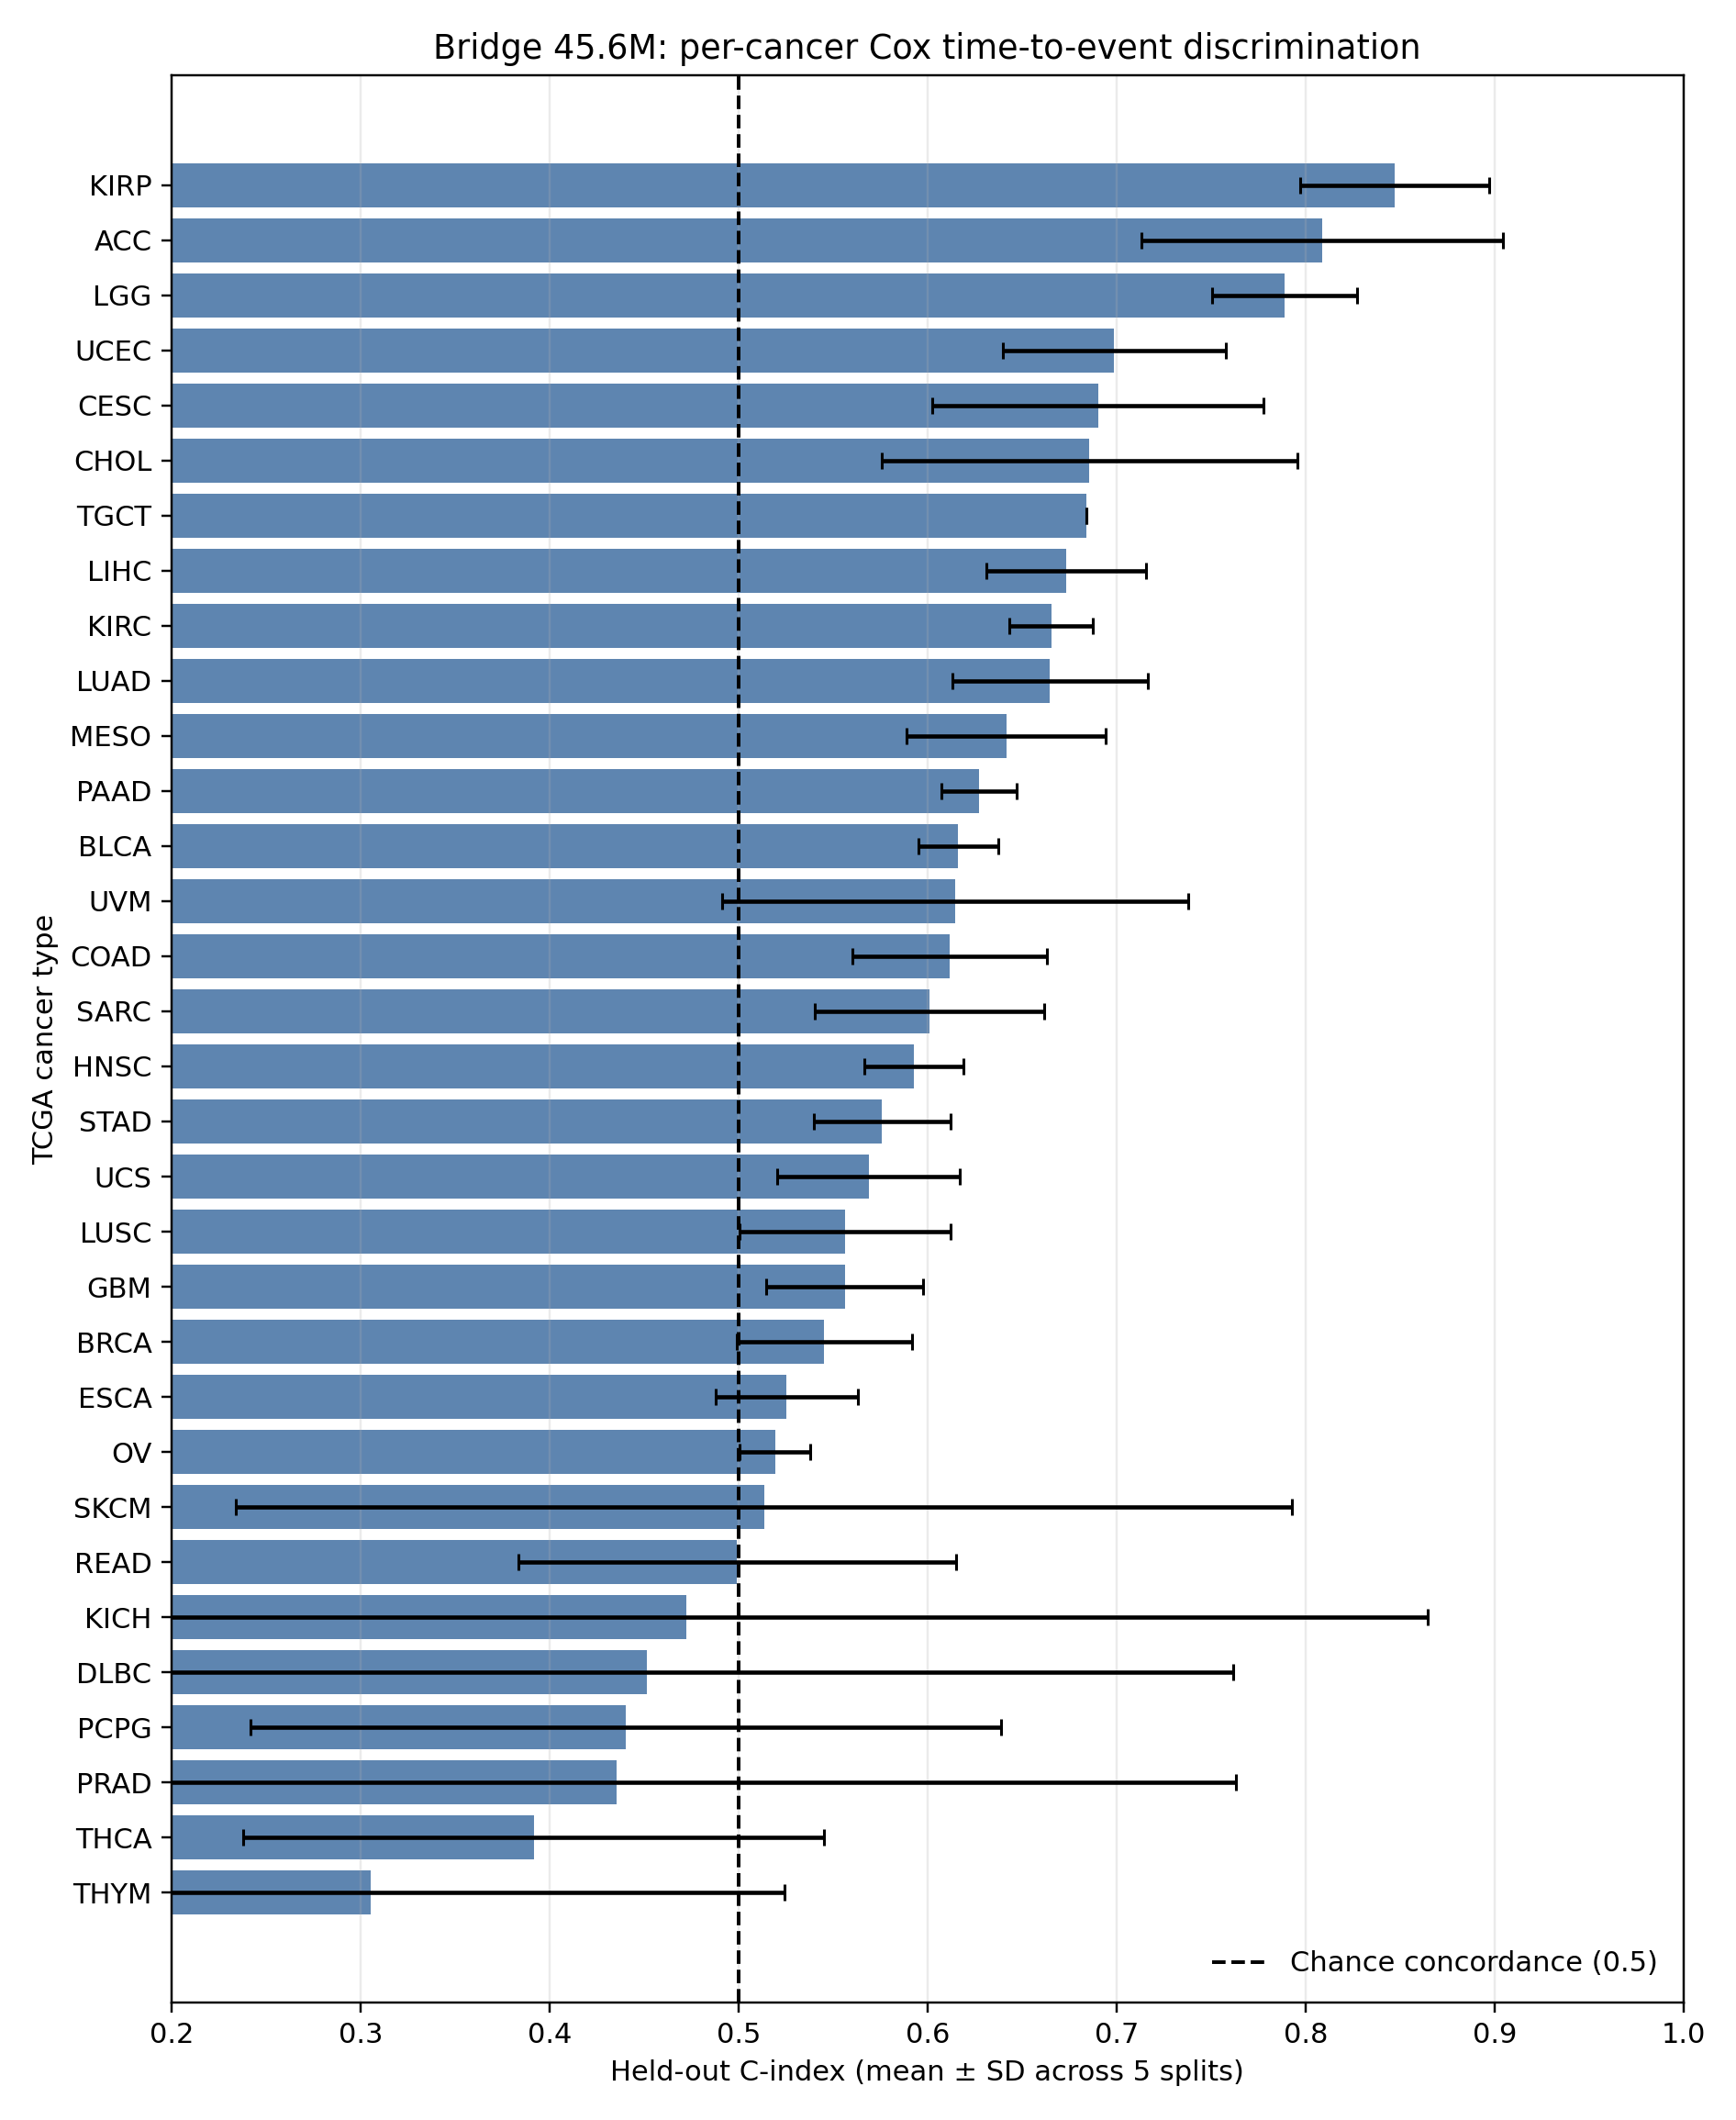

In [22]:
display(Image(filename=str(FIGURES / 'bridge_cox_per_cancer_c_index_bar.png')))

### A3 Mean pooling versus learned attention pooling

This exploratory one-seed ablation keeps the 45.6M FM completely frozen and changes only aggregation of its 15,165 contextual 512-D gene tokens. Mean pooling is compared with a learned content-attention weight over every gene on the identical seed-0 patient split and downstream MLP settings. FM inputs are `log1p(TPM)`, matching checkpoint `r7hnr92k`; the full-expression control elsewhere uses `log1p(CPM)`. Because attention was run once, no attention SD is reported.

**Result.** Attention pooling did not improve seed-0 classification (weighted F1 0.9735 versus 0.9737) and reduced survival discrimination: pooled C-index 0.7529 versus 0.7607, weighted within-cancer C-index 0.5836 versus 0.6109, and macro within-cancer C-index 0.5932 versus 0.6096. This exploratory result does not support mean pooling as the principal limitation, so additional attention seeds were not run.

Classification: frozen FM pooling ablation


seed,pooling,macro_f1,weighted_f1,balanced_accuracy
0,mean,0.968650,0.973679,0.967240
0,learned_attention,0.966247,0.973470,0.963006


Survival: frozen FM pooling ablation


seed,pooling,c_index,weighted_c_index,macro_c_index
0,mean,0.760718,0.610929,0.609642
0,learned_attention,0.752929,0.583627,0.593173


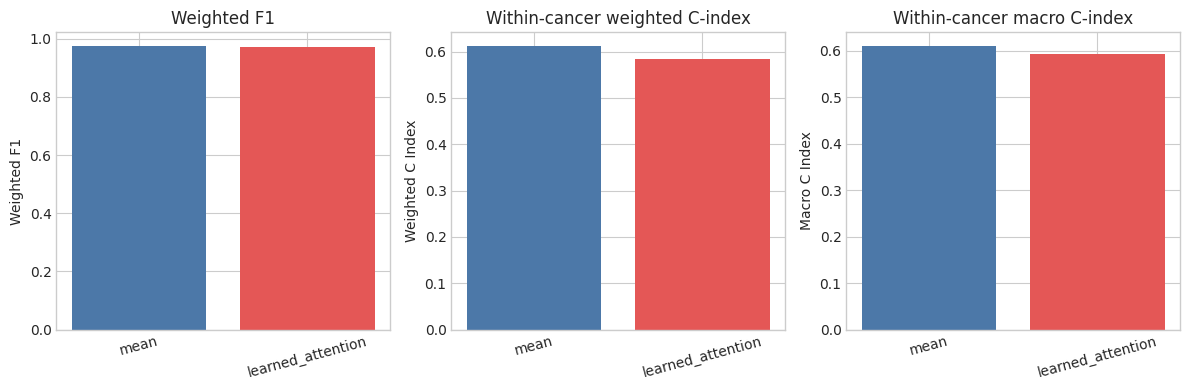

In [23]:
pooling_files = {
    'Classification': RESULTS/'ours_pooling_classification_seed0.parquet',
    'Survival': RESULTS/'ours_pooling_survival_seed0.parquet'}
if not all(path.exists() for path in pooling_files.values()):
    print('Attention-pooling results are not complete. Run pipeline/run_attention_pooling.py; the runner is resumable by seed.')
else:
    pooling_classification = pd.read_parquet(pooling_files['Classification'])
    pooling_survival = pd.read_parquet(pooling_files['Survival'])
    print('Classification: frozen FM pooling ablation')
    display(pooling_classification.style.format({c:'{:.4f}' for c in pooling_classification if c.endswith(('_mean','_sd'))}).hide(axis='index'))
    print('Survival: frozen FM pooling ablation')
    display(pooling_survival.style.format({c:'{:.4f}' for c in pooling_survival if c.endswith(('_mean','_sd'))}).hide(axis='index'))
    fig, axes = plt.subplots(1,3,figsize=(12,4))
    panels = [(pooling_classification,'weighted_f1','Weighted F1'),
              (pooling_survival,'weighted_c_index','Within-cancer weighted C-index'),
              (pooling_survival,'macro_c_index','Within-cancer macro C-index')]
    for ax,(frame,metric,title) in zip(axes,panels):
        frame = frame.set_index('pooling').reindex(['mean','learned_attention']).dropna(how='all')
        ax.bar(frame.index,frame[metric],color=['#4C78A8','#E45756'])
        ax.set(title=title,ylabel=metric.replace('_',' ').title()); ax.tick_params(axis='x',rotation=15)
    fig.tight_layout(); fig.savefig(FIGURES/'ours_mean_vs_attention_pooling.png',dpi=250,bbox_inches='tight'); plt.show()

## B. BulkFormer-parity benchmark

The final Cell Systems release reports TCGA classification weighted F1 = 0.907, but the authors do not release downstream training code or fold assignments. Their released `TCGA_survival.h5ad` contains 10,429 sample rows for 9,679 patients, including 750 repeated-patient rows and 709 normal-tissue aliquots. The literature value is therefore not patient-level paired with the results below.

The conservative local reconstruction uses all 33 TCGA labels, one specimen per patient (primary tumors plus LAML peripheral blood), native model vocabularies, frozen encoders, training-fold-only PCA-128, random forests, and ten fixed patient-level folds. All representations share the same 9,942 patients and folds. Existing caches cover 9,816 patients; only 126 LAML patients required new inference. BulkFormer uses mean pooling, matching the final release notebook example; the inaccessible final downstream implementation leaves pooling and several classifier details ambiguous.

In [24]:
parity_classification = pd.read_csv('results/bulkformer_parity_pan_cancer_classification_summary.csv')
parity_classification[['representation', 'method', 'folds', 'macro_f1_mean',
                       'weighted_f1_mean', 'balanced_accuracy_mean']].round(4)

,representation,method,folds,macro_f1_mean,weighted_f1_mean,balanced_accuracy_mean
0,bulkformer_147m,pca128_random_forest,10,0.8608,0.8966,0.8551
1,bulkformer_50m,pca128_random_forest,10,0.8453,0.8799,0.8387
2,full_raw_expression,pca128_random_forest,10,0.8891,0.9167,0.8903
3,full_raw_expression,random_forest,10,0.8968,0.9304,0.8952
4,ours_45.6m,pca128_random_forest,10,0.8575,0.8884,0.8588


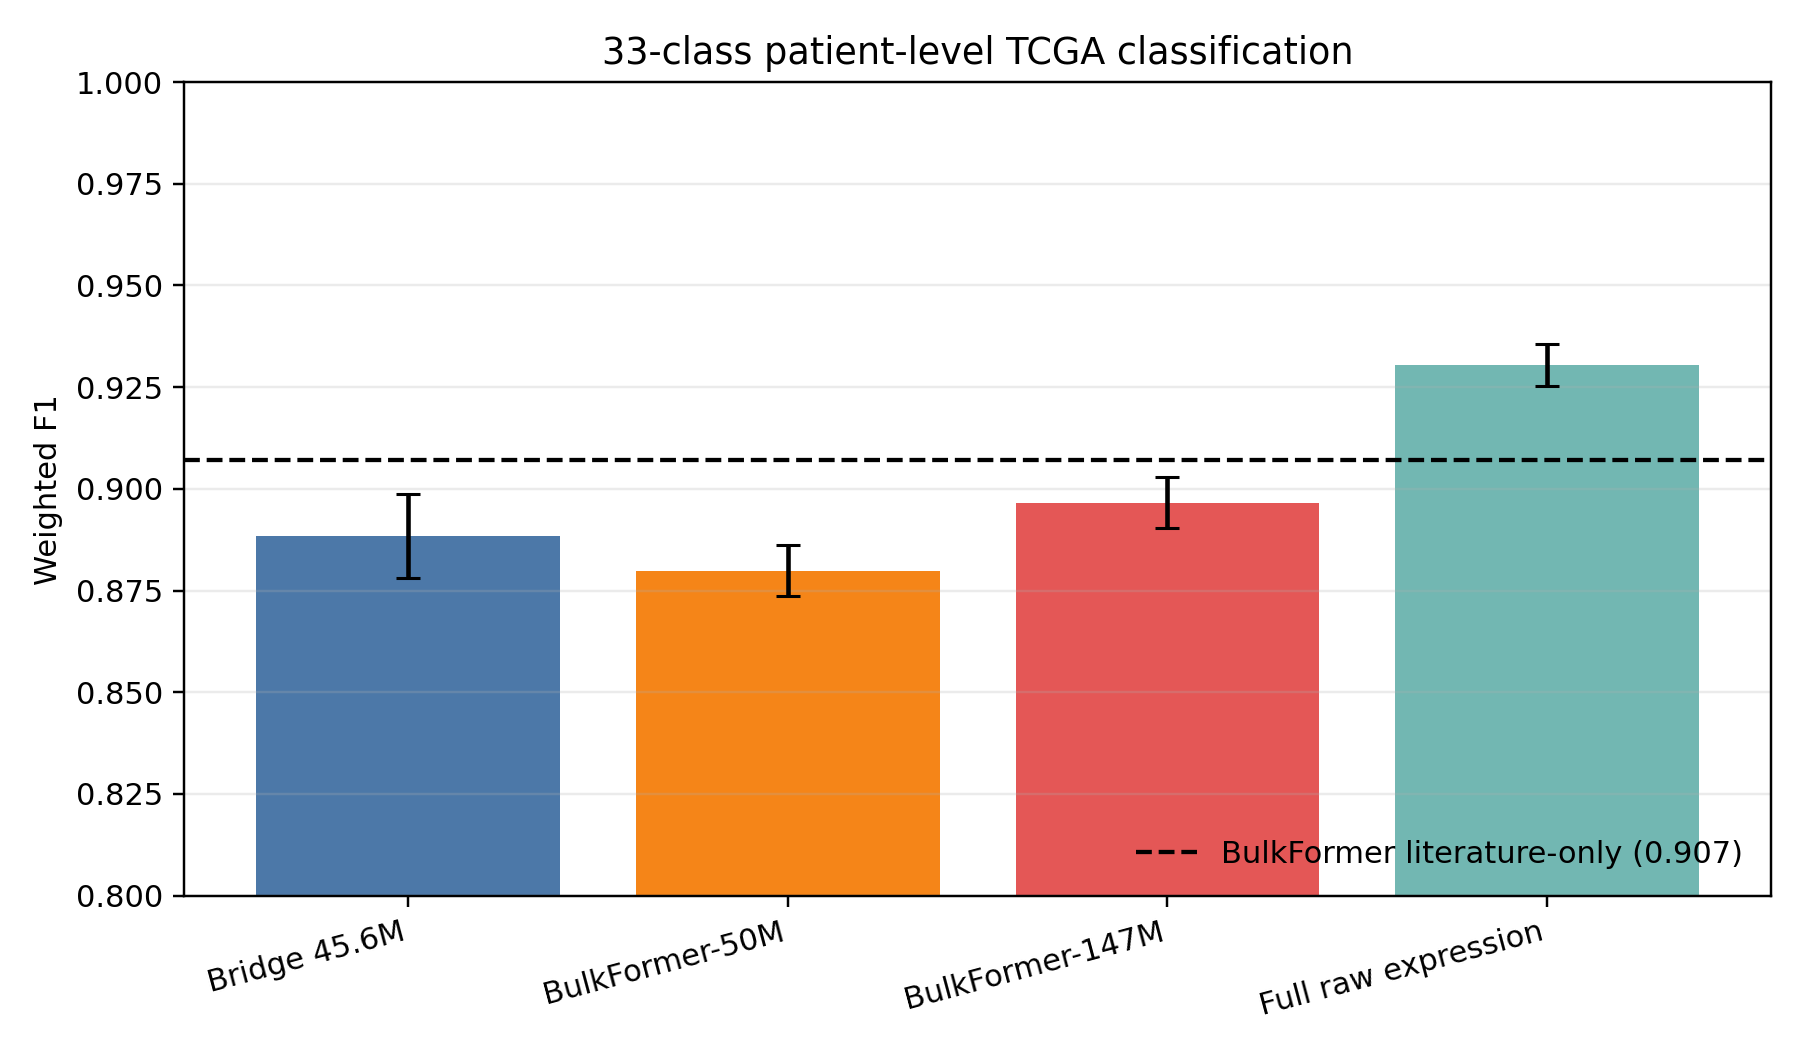

In [25]:
from IPython.display import Image
display(Image(filename=str(FIGURES / 'bulkformer_parity_pan_cancer_classification.png')))

### B1. Pan-cancer classification conclusion

On identical patient-level folds, full raw expression is strongest. BulkFormer-147M is the strongest frozen FM, Bridge 45.6M is next, and BulkFormer-50M is lower. The authors' 0.907 is shown only as a literature reference because their released cohort includes repeated patients and normal aliquots and their exact folds/code are unavailable.

### B2. BulkFormer-style alive/dead prognosis

This binary endpoint discards follow-up time and censoring structure. It is reported separately and is not interchangeable with the Cox/C-index benchmark in section A2. The final release retains prognosis modeling and releases `OS` plus `OS.time`, but does not publish final prognosis metrics in the repository README; AUROC/AUPRC = 0.747/0.549 are historical preprint values only.

In [26]:
parity_prognosis = pd.read_csv('results/bulkformer_parity_alive_dead_prognosis_summary.csv')
parity_prognosis[['representation', 'method', 'folds', 'auroc_mean', 'auprc_mean']].round(4)

,representation,method,folds,auroc_mean,auprc_mean
0,bulkformer_147m,pca128_random_forest,10,0.7474,0.5266
1,bulkformer_50m,pca128_random_forest,10,0.7337,0.5091
2,full_raw_expression,pca128_random_forest,10,0.7611,0.5477
3,full_raw_expression,random_forest,10,0.7611,0.5523
4,ours_45.6m,pca128_random_forest,10,0.7492,0.5273


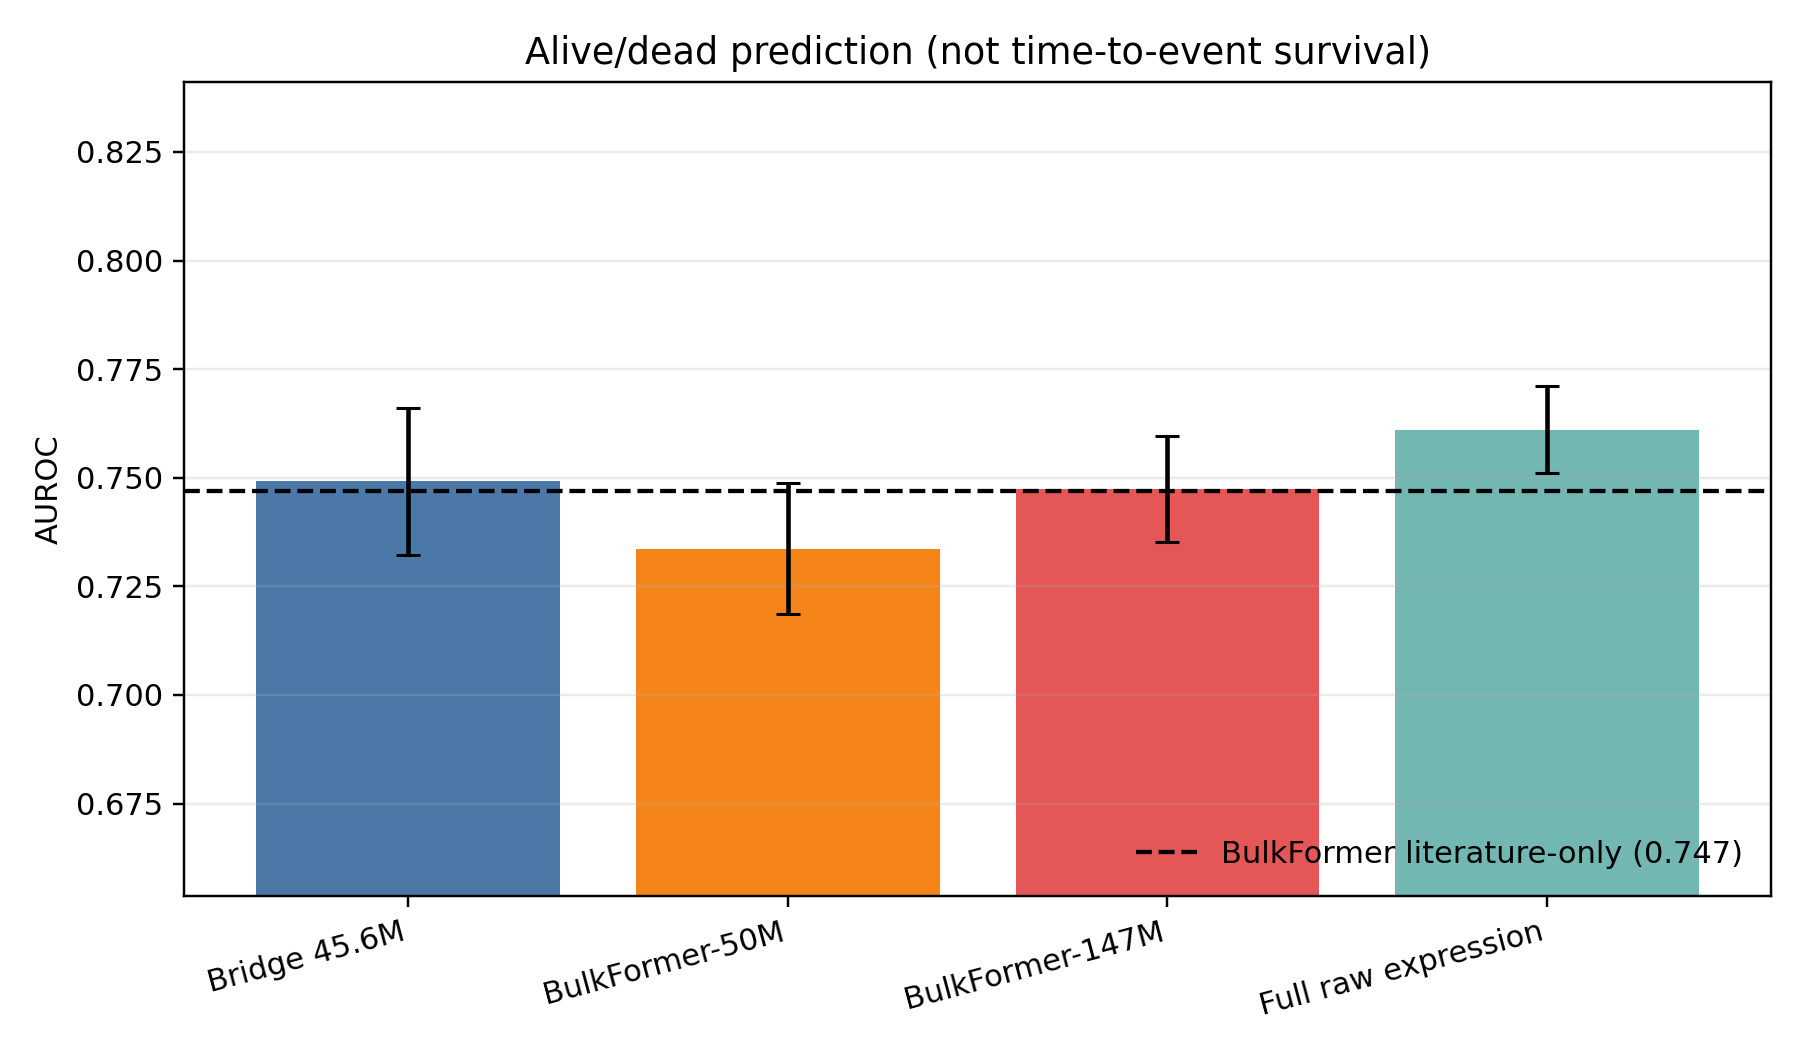

In [27]:
display(Image(filename=str(FIGURES / 'bulkformer_parity_alive_dead_prognosis.png')))

### B3. Per-cancer alive/dead performance

The heatmap below calculates AUROC separately within each cancer from pooled out-of-fold predictions, so every patient contributes exactly once per representation. `NA` means that a cancer has only one observed outcome class and AUROC is undefined. Small-event cancers should be interpreted descriptively; this remains a binary alive/dead analysis rather than censoring-aware survival.

In [28]:
per_cancer_prognosis = pd.read_csv('results/bulkformer_parity_alive_dead_prognosis_per_cancer.csv')
display(per_cancer_prognosis.sort_values(['cancer_label', 'representation'])
        [['cancer_label', 'representation', 'patients', 'events', 'alive', 'auroc', 'auprc']]
        .style.format({'auroc': '{:.3f}', 'auprc': '{:.3f}'}).hide(axis='index'))

cancer_label,representation,patients,events,alive,auroc,auprc
ACC,bulkformer_147m,79,28,51,0.745,0.628
ACC,bulkformer_50m,79,28,51,0.764,0.605
ACC,full_raw_expression,79,28,51,0.801,0.684
ACC,ours_45.6m,79,28,51,0.782,0.640
BLCA,bulkformer_147m,408,179,229,0.624,0.600
BLCA,bulkformer_50m,408,179,229,0.562,0.513
BLCA,full_raw_expression,408,179,229,0.586,0.501
BLCA,ours_45.6m,408,179,229,0.573,0.494
BRCA,bulkformer_147m,1093,151,942,0.538,0.164
BRCA,bulkformer_50m,1093,151,942,0.538,0.159


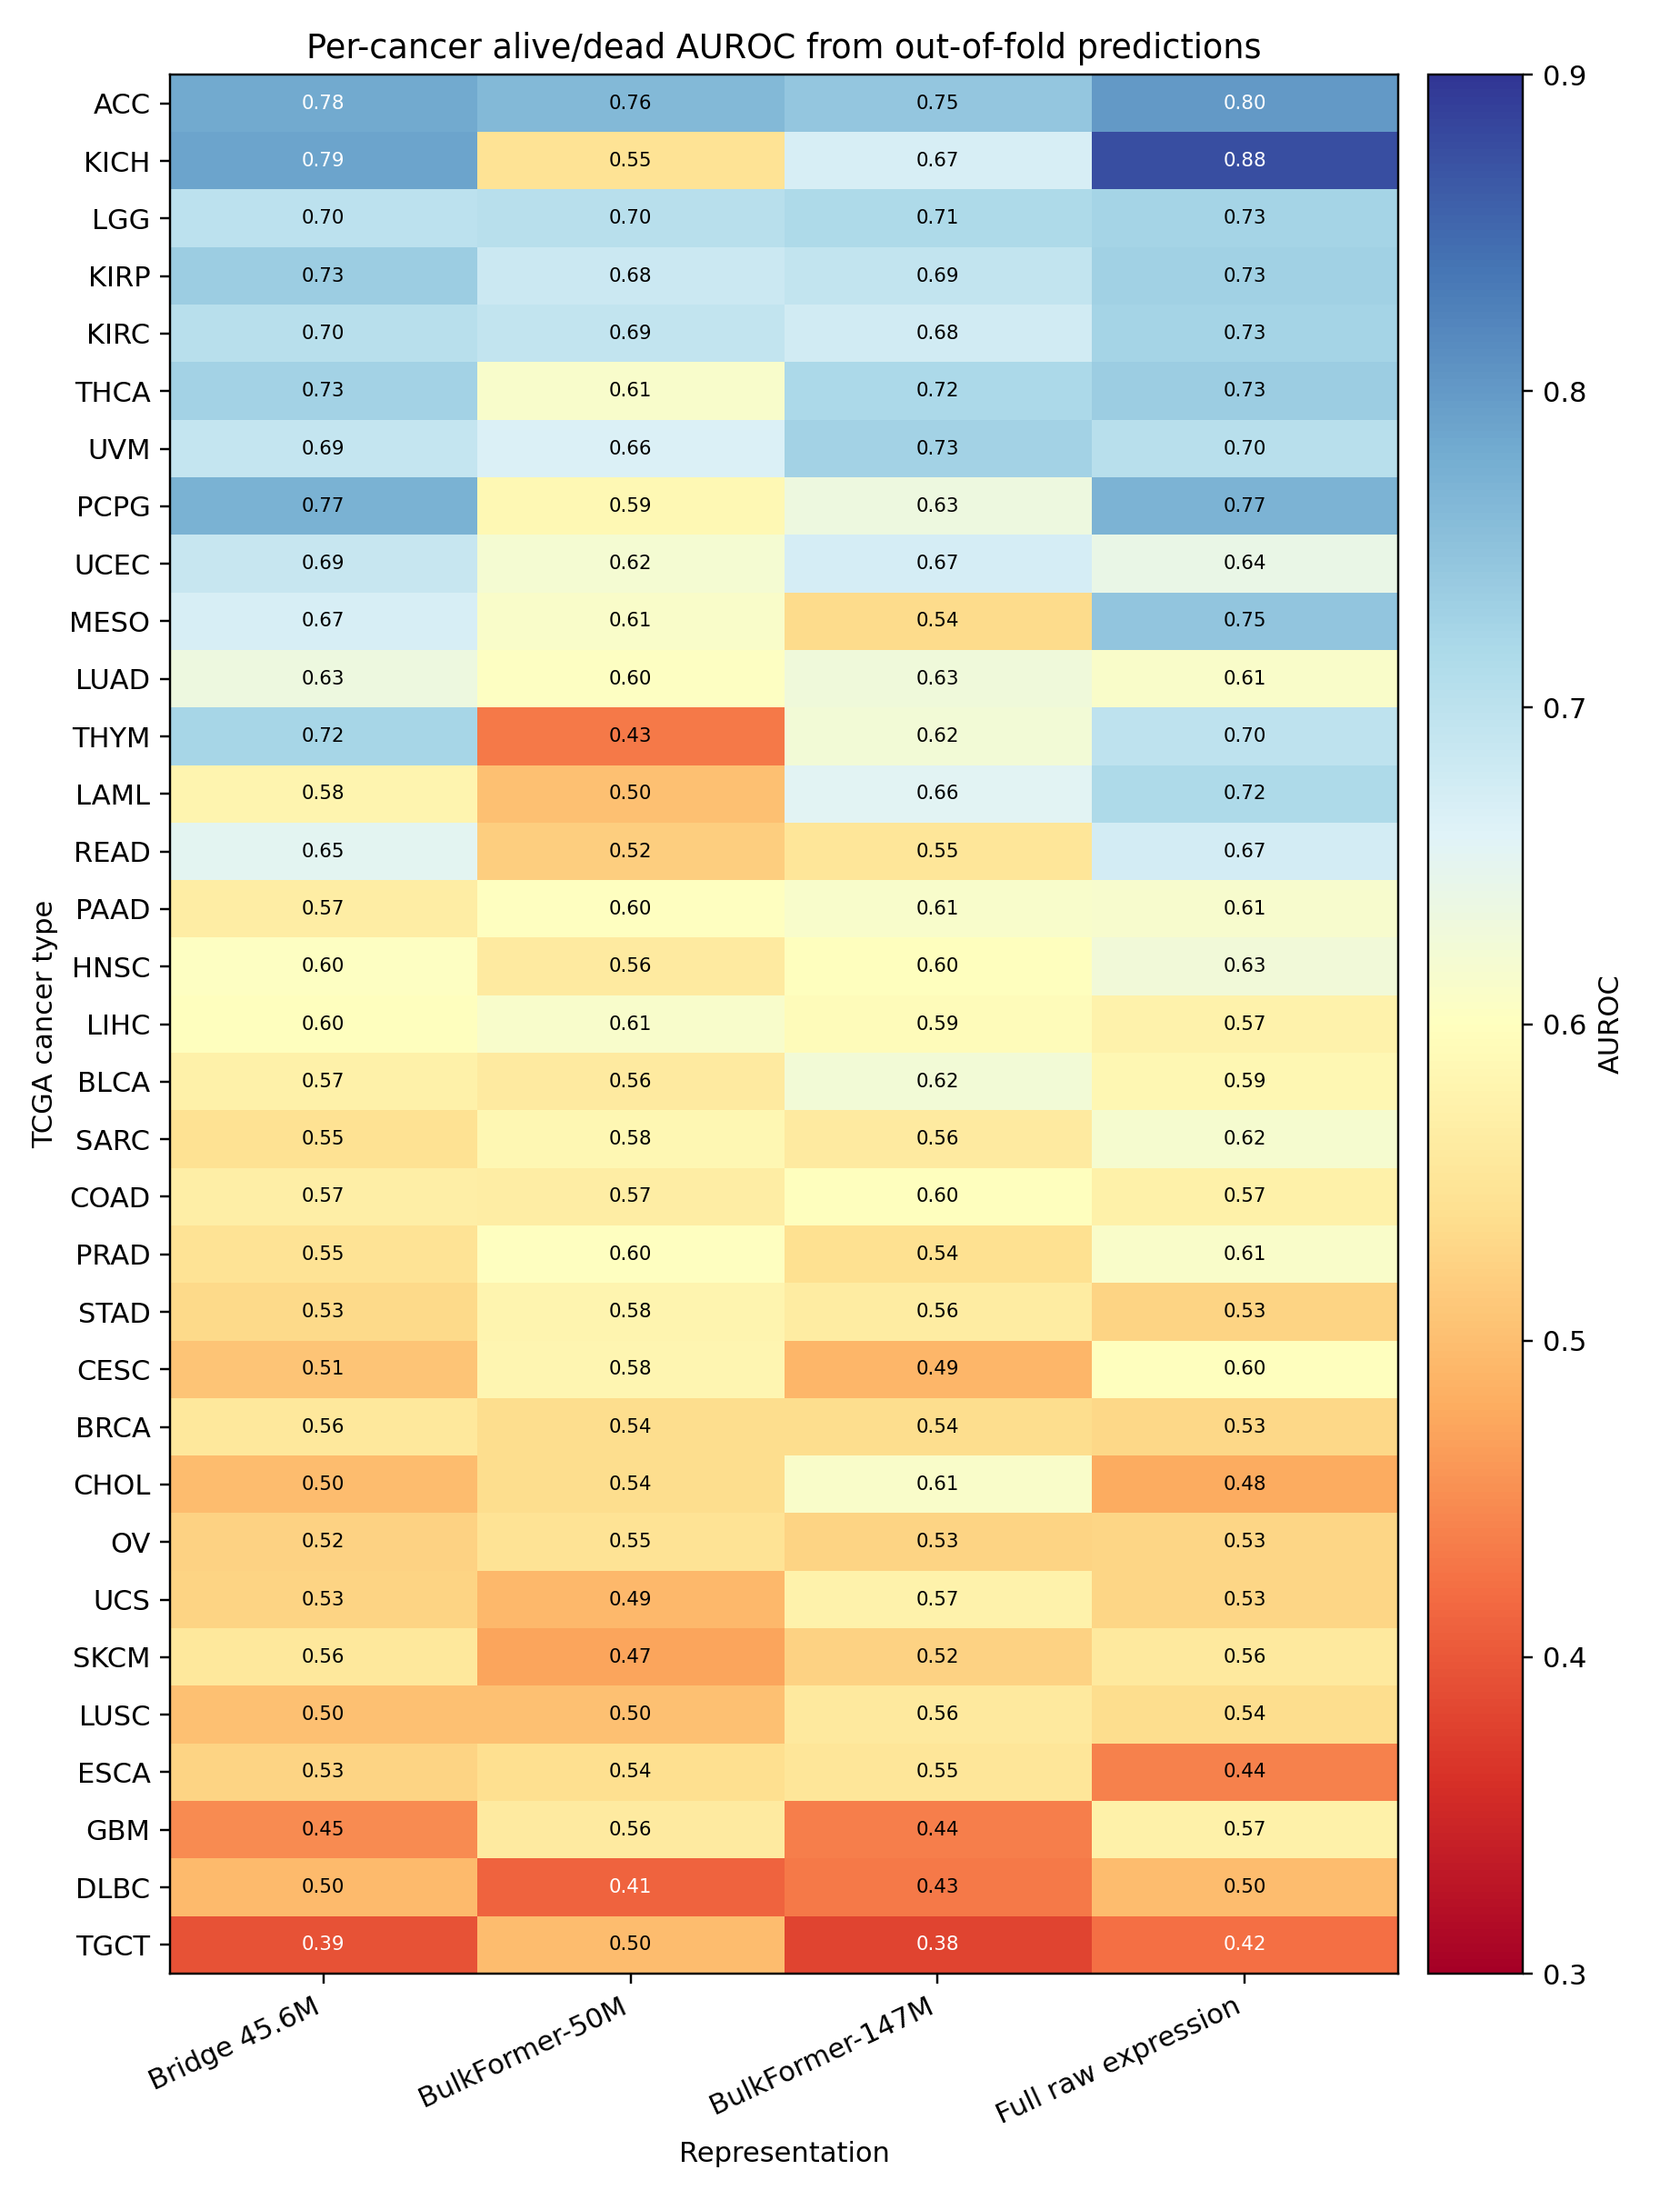

In [29]:
display(Image(filename=str(FIGURES / 'bulkformer_parity_alive_dead_prognosis_per_cancer.png')))

### B3.1 Direct visual comparison with Cox survival

For visibility, the two per-cancer plots are aligned below. The left panel is the BulkFormer-style binary alive/dead endpoint (AUROC); the right panel is the censoring-aware Cox endpoint (C-index). The metrics are different and should not be numerically equated. LAML is `NA` for Cox because the original primary-tumor Cox cohort contains 32 solid-cancer projects.

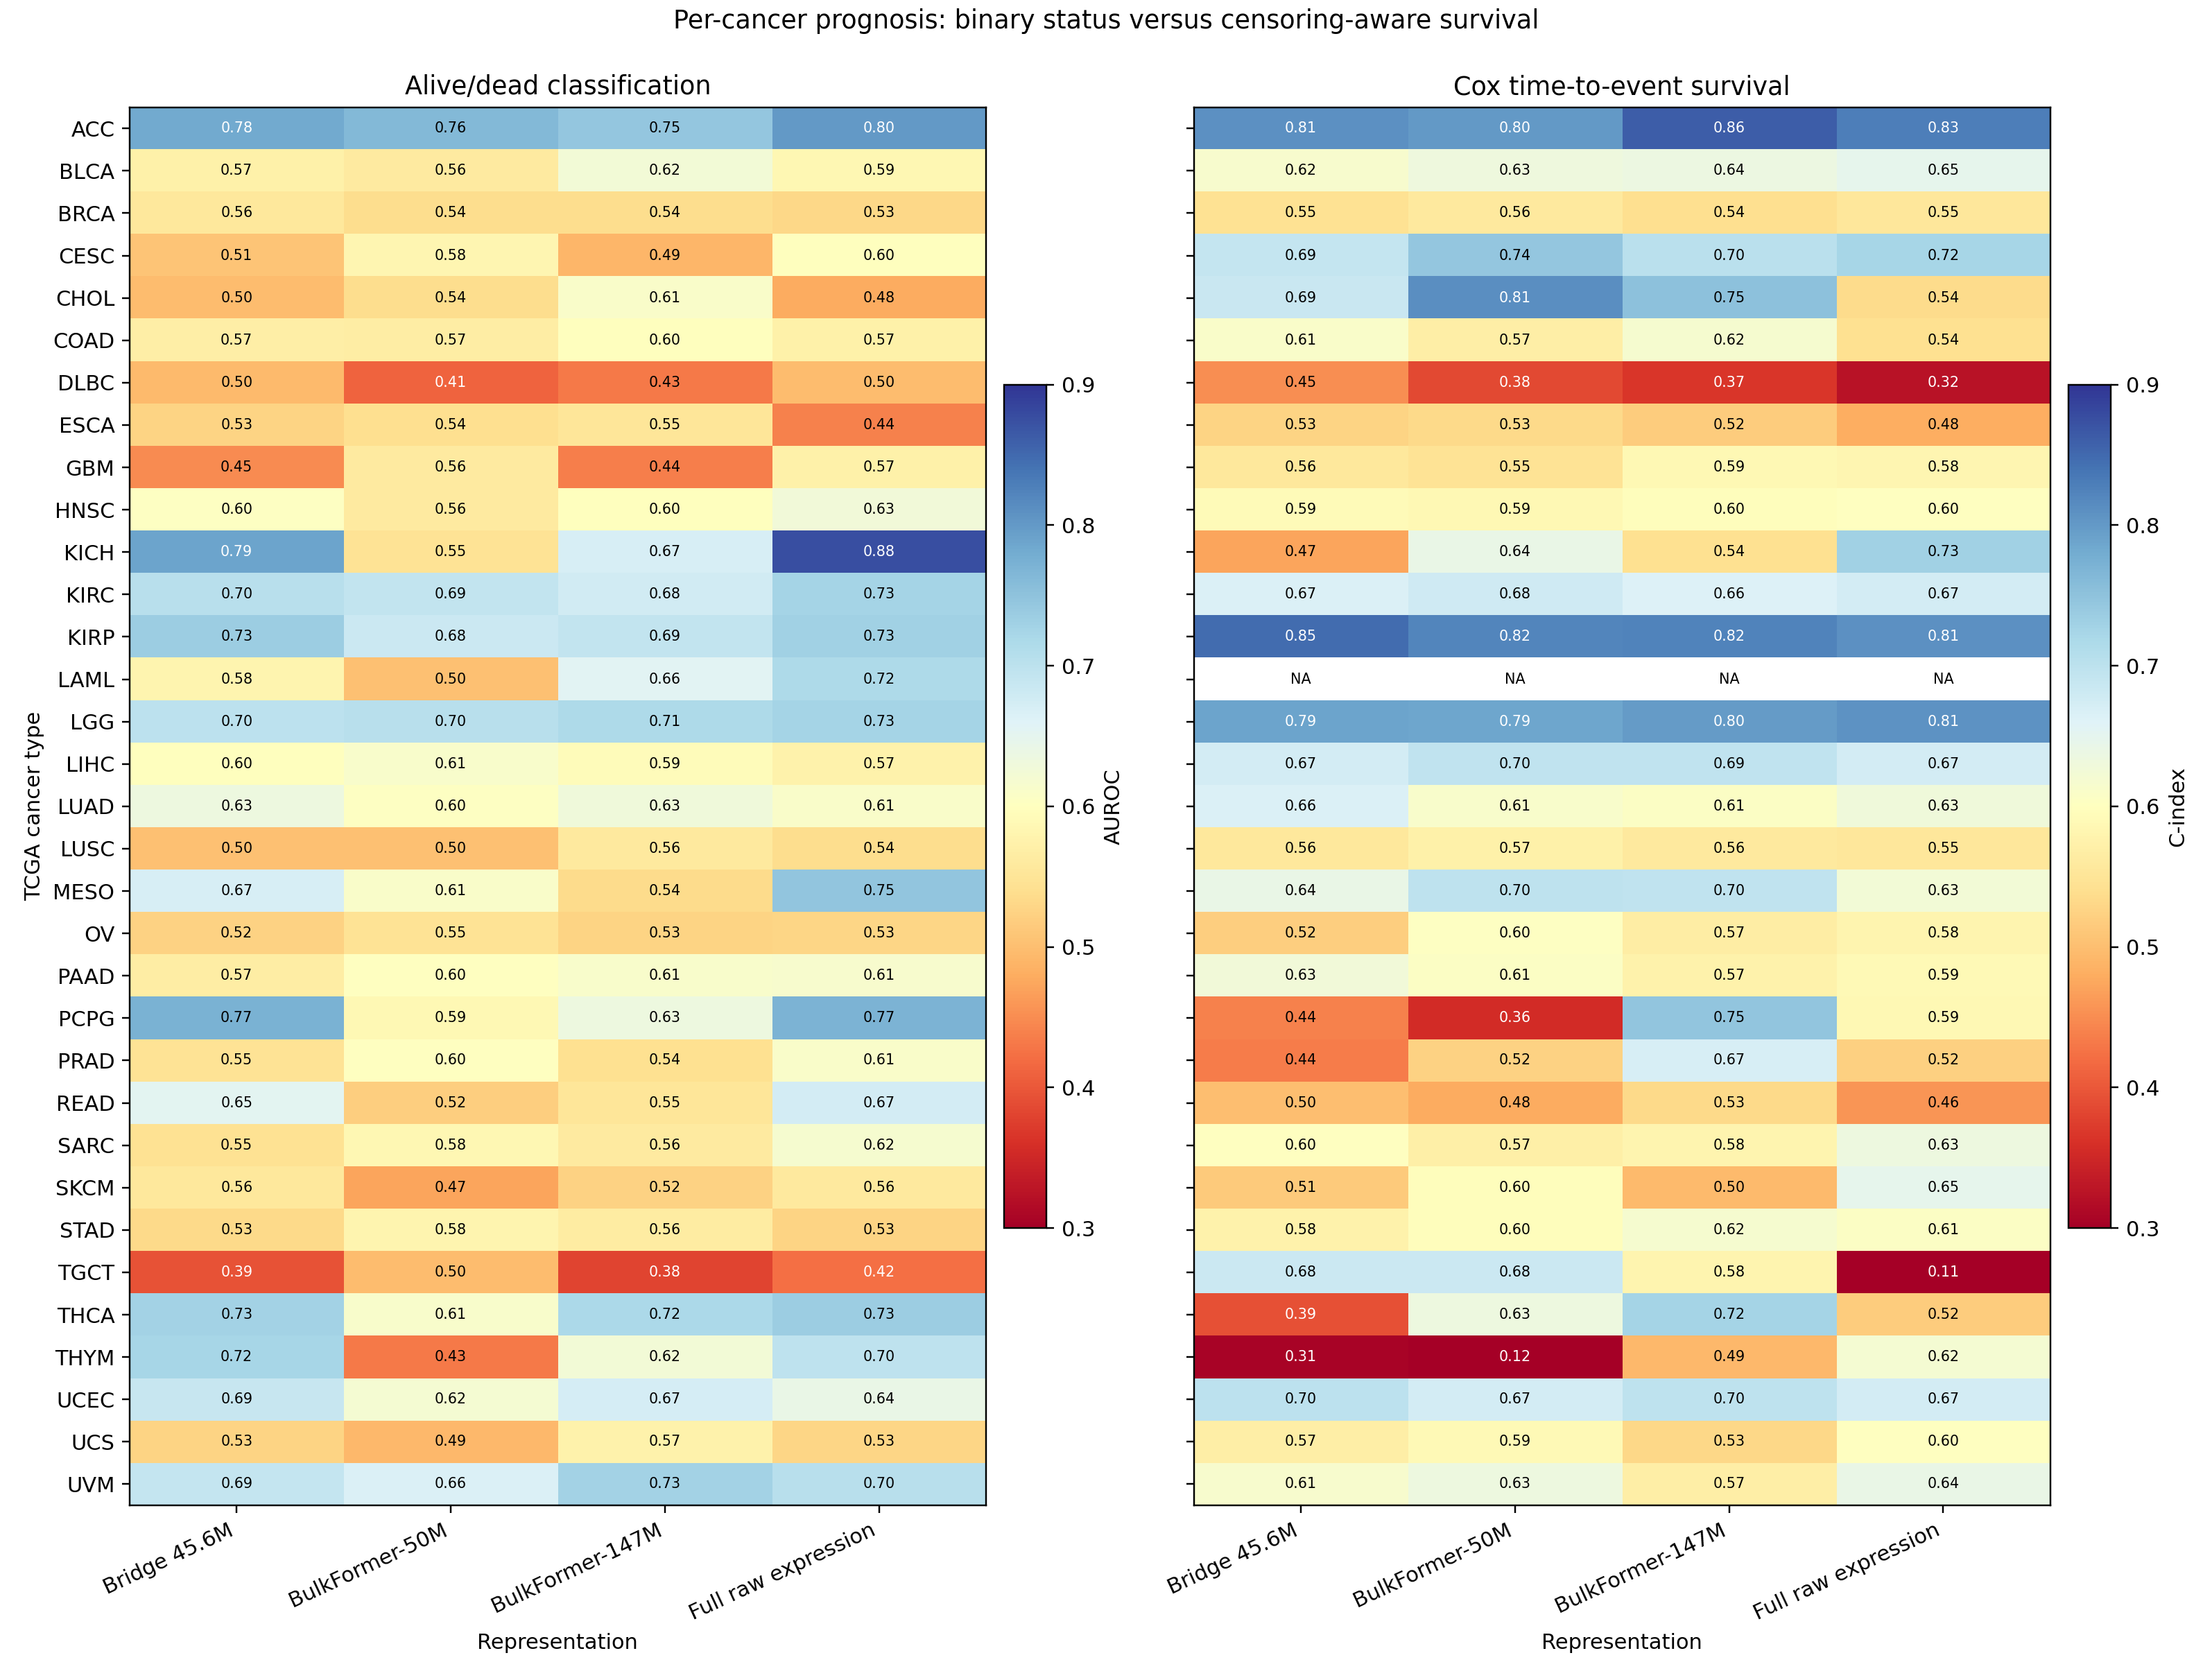

In [30]:
display(Image(filename=str(FIGURES / 'per_cancer_alive_dead_vs_cox_comparison.png')))

### B4. Prognosis conclusion

Raw expression is strongest for alive/dead prediction. Bridge 45.6M and BulkFormer-147M are effectively tied in mean AUROC/AUPRC on the common patient-level folds; BulkFormer-50M is lower. This does not alter the stronger scientific status of the existing time-to-event Cox analysis.

## C. Published reference values

These values are transcribed from the BulkRNABert paper. They provide context only: their preprocessing, splits, heads, and pretraining exposure differ from the common local benchmark above.

In [31]:
published = pd.read_parquet(RESULTS / 'published_reference_results.parquet')
display(published.style.format({'mean':'{:.3f}','sd':'{:.3f}'}).hide(axis='index'))

task,method,metric,mean,sd
five_cohort_classification,NMF-128+SVM (published),weighted_f1,0.898,0.018
five_cohort_classification,PCA-256+SVM (published),weighted_f1,0.968,0.010
five_cohort_classification,BulkRNABert(GTEx ENCODE)+SVM,weighted_f1,0.977,0.008
five_cohort_classification,BulkRNABert(TCGA)+SVM,weighted_f1,0.991,0.005
pan_cancer_classification,BulkRNABert(GTEx ENCODE)+SVM,macro_f1,0.887,0.005
pan_cancer_classification,BulkRNABert(GTEx ENCODE)+SVM,weighted_f1,0.918,0.005
pan_cancer_survival,BulkRNABert(GTEx ENCODE),c_index,0.753,0.009
pan_cancer_survival,BulkRNABert(GTEx ENCODE),weighted_c_index,0.621,0.015
pan_cancer_survival,BulkRNABert(TCGA),c_index,0.765,0.011
pan_cancer_survival,BulkRNABert(TCGA),weighted_c_index,0.642,0.014


### C1 Complete comparison tables

These tables place all locally evaluated results and applicable published references in one view. `Local common splits` and `Published authors’ splits` must be interpreted separately; differences between those groups are descriptive rather than paired statistical comparisons.

In [32]:
local_classification = classification.assign(
    source='Local native-head splits', method=classification['Model'], input_features=classification['native_features'],
    task='five_cohort_classification')[['task','source','method','probe','splits','input_features',
        'macro_f1_mean','macro_f1_sd','weighted_f1_mean','weighted_f1_sd',
        'balanced_accuracy_mean','balanced_accuracy_sd']]
published_classification = published[published.task.eq('five_cohort_classification')].copy()
published_classification = published_classification.pivot_table(
    index=['task','method'], columns='metric', values=['mean','sd'], aggfunc='first')
published_classification.columns = [f'{metric}_{stat}' for stat, metric in published_classification.columns]
published_classification = published_classification.reset_index().assign(
    source='Published authors’ splits', probe='As published', splits=5, input_features=np.nan)
linear_classification = classification_linear.assign(
    Model=classification_linear.representation.map(labels), source='Local PCA-128 controls',
    method=lambda frame: frame.Model, task='five_cohort_classification', input_features=128)[
    ['task','source','method','probe','splits','input_features','macro_f1_mean','macro_f1_sd',
     'weighted_f1_mean','weighted_f1_sd','balanced_accuracy_mean','balanced_accuracy_sd']]
for column in local_classification.columns:
    if column not in published_classification: published_classification[column] = np.nan
classification_all = pd.concat([local_classification, linear_classification,
    published_classification[local_classification.columns]], ignore_index=True)
classification_all.to_parquet(RESULTS/'classification_all_results.parquet', index=False)
classification_all.to_csv(RESULTS/'classification_all_results.csv', index=False)
print('All five-cohort classification results')
display(classification_all.style.format({c:'{:.4f}' for c in classification_all if c.endswith(('_mean','_sd'))},
    na_rep='—').hide(axis='index'))

local_survival = survival.assign(source='Local native-head splits', method=survival['Model'],
    input_features=survival['native_features'], task='pan_cancer_survival')[['task','source','method','probe','splits','input_features','c_index_mean','c_index_sd',
        'weighted_c_index_mean','weighted_c_index_sd','macro_c_index_mean','macro_c_index_sd']]
published_survival_all = published[published.task.eq('pan_cancer_survival')].copy()
published_survival_all = published_survival_all.pivot_table(
    index=['task','method'], columns='metric', values=['mean','sd'], aggfunc='first')
published_survival_all.columns = [f'{metric}_{stat}' for stat, metric in published_survival_all.columns]
published_survival_all = published_survival_all.reset_index().assign(
    source='Published authors’ splits', probe='As published', splits=5, input_features=np.nan)
linear_survival = survival_linear.assign(Model=survival_linear.representation.map(labels),
    source='Local PCA-128 controls', method=lambda frame: frame.Model, task='pan_cancer_survival',
    input_features=128)[['task','source','method','probe','splits','input_features','c_index_mean','c_index_sd',
    'weighted_c_index_mean','weighted_c_index_sd','macro_c_index_mean','macro_c_index_sd']]
for column in local_survival.columns:
    if column not in published_survival_all: published_survival_all[column] = np.nan
survival_all = pd.concat([local_survival, linear_survival,
    published_survival_all[local_survival.columns]], ignore_index=True)
survival_all.to_parquet(RESULTS/'survival_all_results.parquet', index=False)
survival_all.to_csv(RESULTS/'survival_all_results.csv', index=False)
print('All pan-cancer survival results')
display(survival_all.style.format({c:'{:.4f}' for c in survival_all if c.endswith(('_mean','_sd'))},
    na_rep='—').hide(axis='index'))

All five-cohort classification results


task,source,method,probe,splits,input_features,macro_f1_mean,macro_f1_sd,weighted_f1_mean,weighted_f1_sd,balanced_accuracy_mean,balanced_accuracy_sd
five_cohort_classification,Local native-head splits,BulkFormer-147M,native_mlp_256_128,5,643.000000,0.9837,0.0066,0.9861,0.0055,0.9833,0.0065
five_cohort_classification,Local native-head splits,BulkFormer-50M,native_mlp_256_128,5,259.000000,0.9751,0.0073,0.9796,0.0061,0.9750,0.0088
five_cohort_classification,Local native-head splits,Full raw expression,native_mlp_256_128,5,25150.000000,0.9886,0.0046,0.9904,0.0040,0.9894,0.0046
five_cohort_classification,Local native-head splits,Our FM (45.6M),native_mlp_256_128,5,512.000000,0.9796,0.0068,0.9830,0.0057,0.9794,0.0079
five_cohort_classification,Local PCA-128 controls,BulkFormer-147M,linear_svm,5,128.000000,0.9883,0.0066,0.9904,0.0053,0.9883,0.0070
five_cohort_classification,Local PCA-128 controls,BulkFormer-147M,logistic_regression,5,128.000000,0.9849,0.0063,0.9873,0.0054,0.9848,0.0063
five_cohort_classification,Local PCA-128 controls,BulkFormer-50M,linear_svm,5,128.000000,0.9776,0.0048,0.9823,0.0036,0.9772,0.0055
five_cohort_classification,Local PCA-128 controls,BulkFormer-50M,logistic_regression,5,128.000000,0.9760,0.0078,0.9805,0.0062,0.9763,0.0090
five_cohort_classification,Local PCA-128 controls,Our FM (45.6M),linear_svm,5,128.000000,0.9877,0.0043,0.9895,0.0037,0.9879,0.0052
five_cohort_classification,Local PCA-128 controls,Our FM (45.6M),logistic_regression,5,128.000000,0.9846,0.0085,0.9870,0.0070,0.9850,0.0091


All pan-cancer survival results


task,source,method,probe,splits,input_features,c_index_mean,c_index_sd,weighted_c_index_mean,weighted_c_index_sd,macro_c_index_mean,macro_c_index_sd
pan_cancer_survival,Local native-head splits,BulkFormer-147M,native_mlp_512_256_cox,5,643.000000,0.7620,0.0120,0.6320,0.0202,0.6242,0.0225
pan_cancer_survival,Local native-head splits,BulkFormer-50M,native_mlp_512_256_cox,5,259.000000,0.7588,0.0113,0.6168,0.0329,0.6119,0.0217
pan_cancer_survival,Local native-head splits,Full raw expression,native_mlp_512_256_cox,5,25150.000000,0.7610,0.0146,0.6145,0.0136,0.6119,0.0190
pan_cancer_survival,Local native-head splits,Our FM (45.6M),native_mlp_512_256_cox,5,512.000000,0.7597,0.0111,0.5995,0.0260,0.5963,0.0350
pan_cancer_survival,Local PCA-128 controls,BulkFormer-147M,pca128_cox,5,128.000000,0.7538,0.0119,0.6177,0.0153,0.6140,0.0238
pan_cancer_survival,Local PCA-128 controls,BulkFormer-50M,pca128_cox,5,128.000000,0.7512,0.0075,0.6228,0.0209,0.6101,0.0223
pan_cancer_survival,Local PCA-128 controls,Our FM (45.6M),pca128_cox,5,128.000000,0.7578,0.0138,0.6237,0.0233,0.6278,0.0226
pan_cancer_survival,Local PCA-128 controls,Raw expression PCA control,pca128_cox,5,128.000000,0.7647,0.0132,0.6262,0.0101,0.6211,0.0130
pan_cancer_survival,Published authors’ splits,BulkRNABert(GTEx ENCODE),As published,5,—,0.7530,0.0090,0.6210,0.0150,—,—
pan_cancer_survival,Published authors’ splits,BulkRNABert(TCGA),As published,5,—,0.7650,0.0110,0.6420,0.0140,—,—


## 5. Conservative interpretation

With native vocabularies and complete frozen representations, all models distinguish the five cancer groups well. Full 25,150-feature expression is strongest (weighted F1 0.9904), followed by BulkFormer-147M (0.9861), our 45.6M FM (0.9830), and BulkFormer-50M (0.9796). Thus, despite its smaller 15,165-gene vocabulary, our model remains competitive without forcing competitors into that vocabulary. Pooled pan-cancer survival discrimination is nearly tied (mean C-index 0.759–0.762), whereas BulkFormer-147M is strongest on weighted and macro within-cohort C-index; our model is lower and more variable on those endpoints. The PCA-128 linear results are secondary controls, not the primary comparison. These findings support useful transferable representations but not a universal advantage over full expression or larger models. Published values use the authors' own splits and training procedures, and pretraining exposure is not uniform—particularly for TCGA-derived models—so this benchmark measures downstream utility rather than strict unseen-sample generalization.